# Emotion PCA × Jacobian lens — assembled results

Every number below is **read from artefacts already on disk** under
`outputs/*/results/phases/`. Nothing here loads a model, touches a GPU, hits the
network, or reads R2. If an artefact is missing the cell prints what is missing and
continues.

## How to run this

The system `python3` is Homebrew 3.14 with no packages. **Use the conda `base`
environment**, which has pandas / numpy / matplotlib / tokenizers:

```bash
conda activate base                                    # /Users/daylight/miniconda3
python -m ipykernel install --user --name base         # once, if not already listed
jupyter lab analysis/results_notebook.ipynb            # then pick the "base" kernel
```

or headless:

```bash
~/miniconda3/bin/python -m jupyter nbconvert --to notebook --execute \
    --inplace --ExecutePreprocessor.kernel_name=base analysis/results_notebook.ipynb
```

`S.setup()` asserts the interpreter has what it needs and exits loudly if not.

## How this notebook is organised

**This notebook is an outline, not a program.** Each section is one markdown cell of
prose followed by a single call into [`nbsections.py`](nbsections.py). To change what a
section says or computes, edit that one function; to change the order of the argument,
edit this notebook.

| module | holds |
| --- | --- |
| [`nbsections.py`](nbsections.py) | one function per section — all loading, computing, table-building and wording |
| [`nbtools.py`](nbtools.py) | artefact loading, the report accumulator, markdown tables, script classification, the tiered GATE A statistic |
| [`nbfigures.py`](nbfigures.py) | every plot builder; each returns a bare matplotlib figure |
| [`zh_en_glossary.py`](zh_en_glossary.py) | hand-written Chinese↔English matching data — **the only non-derived input** |

The section functions run **once, in order**, and each leaves handles the next expects
(`S.P4`, `S.ALIGN`, `S.TIERS`, …). Re-running a cell out of order will not crash — every
body is wrapped in `Report.guard` — but it may report an artefact as missing. Restart and
run all if in doubt.

Anything a reader should see goes through `Report`, because a plain markdown cell renders
in Jupyter and then vanishes from `RESULTS.md`. `Report.fig()` requires a *How to read it*
and a *What it shows* note per figure, and `S.export()` asserts none were skipped.

## The two runs, side by side throughout

| key | run | design |
| --- | --- | --- |
| `16` | `qwen3-32b_pca-jlens` | 16 balanced circumplex emotions, 400 stories each (+400 neutral) |
| `171` | `qwen3-32b_pca-jlens_171` | all 171 emotions, 200 stories each (+400 neutral); the same 16 are the labelled anchors |

## Reading guide

Verdicts are the pipeline's own, not re-derived. Where a gate said `MURKY`, `REVIEW` or
`EXPLORATORY`, this notebook repeats that word rather than rounding it up. Failures are
in the summary table alongside the successes.

`S.export()` writes [`RESULTS.md`](RESULTS.md) with every table and figure reference. A
companion audit trail for independent checking is in
[`VERIFICATION.md`](VERIFICATION.md).

In [1]:
import sys
from pathlib import Path

_here = Path.cwd()
sys.path.insert(0, str(_here if _here.name == 'analysis' else _here / 'analysis'))

import nbsections as S

S.setup()

interpreter: /Users/daylight/miniconda3/bin/python


root: /Users/daylight/dev/code/emotion_vector_perspectives
figures -> /Users/daylight/dev/code/emotion_vector_perspectives/analysis/figures
  16  qwen3-32b_pca-jlens          ok
 171  qwen3-32b_pca-jlens_171      ok


---

## 0. Setup and provenance

What produced these numbers: model, lens artefact, target block, dataset, storage
prefix. Both runs use the same model checkpoint, the same lens file and the same target
block — the only difference is the stimulus set.

In [2]:
S.provenance()

## 0. Provenance

MISSING: qwen3-32b_pca-jlens_171/phase0_gate.json


**Provenance, both runs**

,field,16,171
0,design,16 balanced emotions x 400 stories,all 171 emotions x 200 stories
1,model,Qwen/Qwen3-32B,Qwen/Qwen3-32B
2,model_sha,9216db5781bf21249d130ec9da846c4624c16137,9216db5781bf21249d130ec9da846c4624c16137
3,dtype / activation dtype,bfloat16 / bfloat16,bfloat16 / bfloat16
4,lens repo,neuronpedia/jacobian-lens,neuronpedia/jacobian-lens
5,lens subfolder,qwen3-32b,qwen3-32b
6,lens file,Qwen3-32B_jacobian_lens.pt,Qwen3-32B_jacobian_lens.pt
7,checkpoint format,fit_checkpoint,fit_checkpoint (from the 16 run)
8,d_model,5120,5120
9,lens prompts (checkpoint n_done),80,80


### FLAG -- the published lens is an interrupted fit

The `qwen3-32b` Jacobian lens on the Hub is a **resumable `fit_checkpoint`**, not a finished lens: it stores `jacobian_sum` (a running sum over prompts) plus `n_done`, and the mean is `jacobian_sum / n_done`. Reading that divisor is what caught the problem.

* checkpoint `n_done` = **80** prompts
* the accompanying `config.yaml` records `prompts_fitted` = **None**
* the fit's own stopping rule was `stop_at_delta = 0.002` over a 10-prompt window with `min_prompts = 100` -- so 80 prompts is short of the fit script's own floor

**Divisor cross-check: DISAGREE.** The normalisation constant is not confirmed. This matters asymmetrically:

* **Top-k readouts are unaffected.** The model's final norm is an RMSNorm, so a globally mis-scaled `J` yields *identical* top-k tokens. Phase 0 verified this numerically (`scale_invariant_top5: true`).
* **Every magnitude-sensitive quantity is suspect**: GATE B's `||J - I||_F / ||I||_F` curve, and any Phase 6 variance split.

Both runs use the same lens file, so this applies to both. `run.py refit_lens` produces a converged alternative; it has not been run.

**Verbatim warning recorded by the pipeline itself:**

> this lens was fitted on 80 prompts -- the published qwen3-32b artefact, whose fit was interrupted well short of its own convergence threshold. A weak PC readout on it cannot be distinguished from lens noise. GATE A is what decides whether the readouts below mean anything; `run.py refit_lens` produces a converged alternative.

---

## 1. Phase 0 — does the lens work at all?

**GATE A** feeds the lens a known concept prompt and asks whether the expected word comes
back near the top, split into *factual* items and *emotion vignettes* because those two
groups behave completely differently.

**GATE B** checks that at the highest fitted block — where the transport spans one
residual block — `J` approaches the identity and the three readouts converge.

Phase 0 ran only for the 16-emotion run. Both runs load the same lens file at the same
target block, so the gate transfers, but it was not independently re-gated.

## 1. Phase 0 -- lens gates

*In plain terms.* *Before trusting anything else: does the lens actually work? Two checks -- can it read a known fact back out of the model, and does it behave sensibly near the top of the network where it has almost no work to do?*

### GATE A

**GATE A -- factual items (16-emotion run; the 171 run did not re-gate)**

,item,expected word,best rank,block,verdict
0,basketball-players,basketball,27,55,near
1,sport-equip-tennis,tennis,1,41,HIT
2,multihop-currency,Italy,5,41,HIT
3,multihop-currency,Italian,9,62,HIT
4,animal-nose-elephant,elephant,3,34,HIT
5,amazon-language,Brazil,16,62,near


...

**GATE A -- split tally**

,group,n,HIT,near,MISS,median best rank
0,factual,6.0,4.0,2.0,0.0,7.0
1,emotion vignettes,10.0,1.0,2.0,7.0,164.5


**Reading.** 5/16 items hit overall, but the split is the result: **4/6** factual items hit (median best rank 7) against **1/10** emotion vignettes (median best rank 164). The single emotion-group HIT is `chess`, the control item in that block, not an emotion word. The lens reads factual content and does not surface English emotion nouns. Section 5 measures why.

### GATE B

**Figure 1 -- GATE B: ||J - I||_F / ||I||_F against block (16-emotion run)**

*In plain terms.* Is the lens trustworthy at all? Near the very top of the model it only has to translate across one small step, so it should barely change anything. This checks whether it does.

*How to read it.* The x-axis is the block index, 0 at the bottom of the stack. The y-axis is how far the transport `J` at that block sits from the identity matrix, in Frobenius norm relative to `||I||`. **Low means `J` is close to a no-op.** At the highest fitted block the transport spans a single residual block, so a well-behaved lens should approach zero on the right.

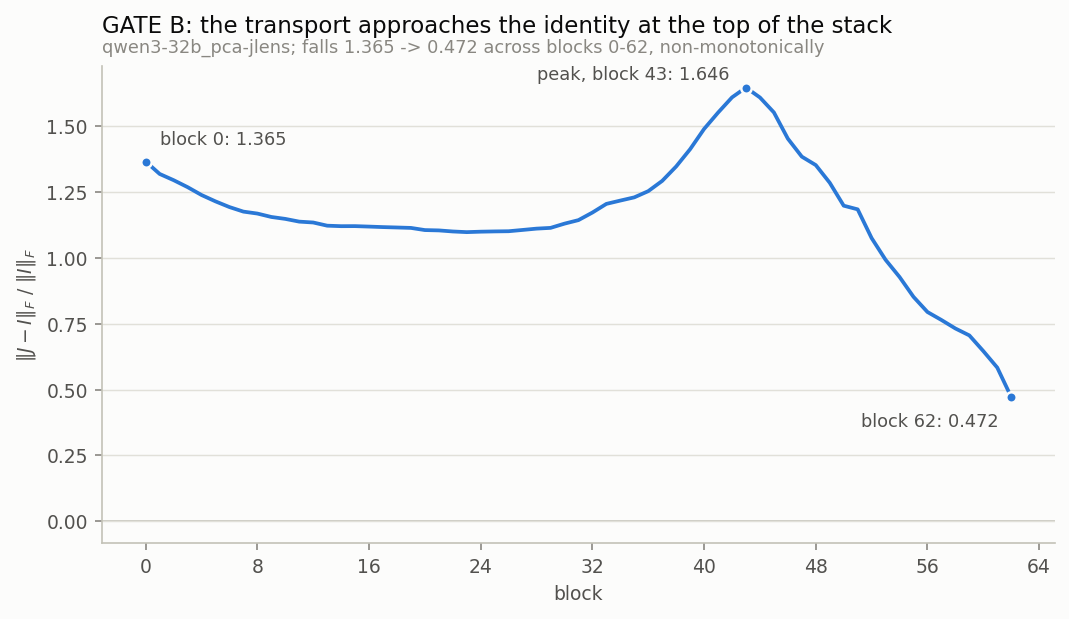

*What it shows.* The distance falls from **1.365** at block 0 to **0.472** at block 62 — the expected direction, so GATE B passes. But the fall is **not monotone**: it climbs to **1.646** at block 43 first. The gate records `falls_with_depth` as an endpoint comparison only, so the mid-stack hump is visible here and nowhere in the JSON. Note also that this y-axis is magnitude-sensitive and the lens divisor is unconfirmed (section 0): the *shape* is scale-free, the absolute values are not.

**GATE B -- agreement at block 62 (probe: `basketball-players`)**

,comparison,value
0,top-1 J-lens == model output,1 / 1
1,top-1 J-lens == logit lens,1 / 1
2,"top-12 overlap, J-lens vs model",10 / 12
3,"top-12 overlap, J-lens vs logit lens",8 / 12


In [3]:
S.phase0()

---

## 2. Phase 1 — stimuli

Does every emotion see the *same* topics, so a difference between two emotion vectors
cannot be a difference between the topics their stories happened to be about? And is any
story short enough that the `token_offset = 50` prefix skip leaves fewer than
`min_pooled_tokens = 10` tokens to pool?

## 2. Phase 1 -- stimuli

*In plain terms.* *The raw material. Thousands of short stories, each written to express one emotion, checked so that every emotion got the same list of topics -- otherwise a difference between two emotions might just be a difference in what their stories were about.*

**Phase 1 -- stimulus design, both runs**

,field,16,171
0,emotions in run,16,171
1,labelled anchors,16,16
2,stimulus rows,6800,34600
3,emotional / neutral,6400 / 400,34200 / 400
4,stories per emotion,400..400,200..200
5,topics total,100,100
6,all emotions share topics,True,True
7,topics exactly matched,True,True
8,"stories per (emotion, topic) cell",4,2
9,split train/val/test,4760/1020/1020,24220/5190/5190


**Phase 1 -- stimulus count by circumplex quadrant**

,quadrant,16,171
0,HA-N,1600,800
1,HA-P,1600,800
2,LA-N,1600,800
3,LA-P,1600,800
4,neutral,400,400
5,unlabelled,0,31000


**Figure 2 -- Phase 1: stimuli per circumplex quadrant, both runs**

*In plain terms.* How many stories went into each corner of the emotion map -- happy-and-excited, happy-and-calm, unhappy-and-excited, unhappy-and-calm -- and how many had no emotion label at all.

*How to read it.* One panel per run; bar height is the number of *story stimuli* in each circumplex quadrant. Blue bars are the four labelled quadrants (HA/LA = high/low arousal, P/N = pleasant/unpleasant). Grey bars carry no circumplex coordinates: `neutral`, and in the 171 run the 155 emotions with no a-priori valence/arousal labels. **The two panels have different y-scales** — compare shapes within a panel, not bar heights across them.

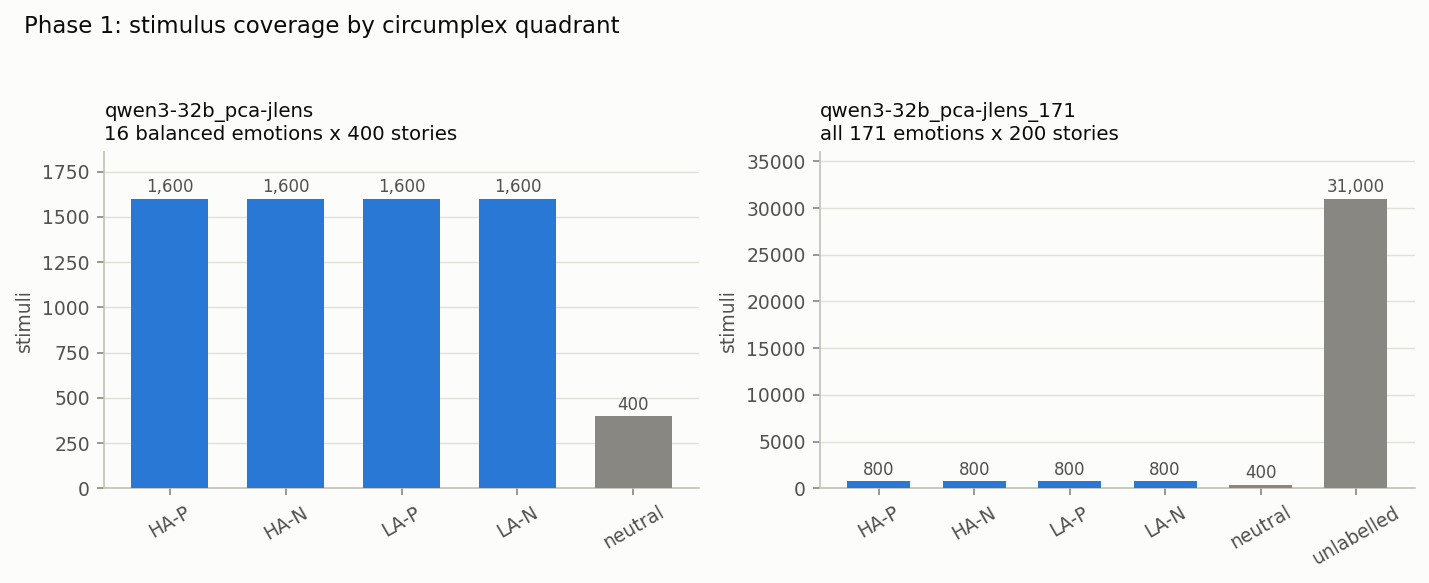

*What it shows.* The 16-emotion run is exactly balanced: 1,600 stimuli in each of the four quadrants. The 171-emotion run has 800 per labelled quadrant against 31,000 unlabelled — so only 3,200 of its 34,200 emotional stimuli carry circumplex coordinates at all. That is why every alignment and AUROC measurement in sections 4 and 5 rests on the same 16 anchors in *both* runs, no matter how many emotions the run contains.

**Reading.**

* **qwen3-32b_pca-jlens** -- 6,800 rows, 16 emotions x 400 stories. All 100 topics appear for every emotion (`exactly_matched = True`), 4 stories per (emotion, topic) cell. Shortest story pools over ~90 tokens against the 60 needed -- **0 stimuli at length risk**.
* **qwen3-32b_pca-jlens_171** -- 34,600 rows, 171 emotions x 200 stories. All 100 topics appear for every emotion (`exactly_matched = True`), 2 stories per (emotion, topic) cell. Shortest story pools over ~76 tokens against the 60 needed -- **0 stimuli at length risk**.

Topic matching is exact in both runs, so a difference between two emotion vectors is not a difference in what the stories were about. No stimulus is short enough for the 50-token prefix skip to starve the pool.

In [4]:
S.phase1()

---

## 3. Phase 2 — emotion vectors and split-half reliability

Each emotion vector is the mean pooled activation at block 31 over that emotion's
stories, minus the grand mean over emotions. Reliability splits the 100 topics into two
halves of 50, builds the vector twice, and takes the cosine. **Centred** cosine is the
number that matters — the raw cosine is inflated by the shared component every mean
activation has.

## 3. Phase 2 -- split-half reliability

*In plain terms.* *Boil each emotion's stories down to a single 'fingerprint' -- an average pattern of activity inside the model -- and check those fingerprints are stable rather than an accident of which stories went in.*

**Phase 2 -- split-half reliability summary**

,field,16,171
0,emotions scored,17,172
1,threshold,0.9,0.9
2,mean centred cosine,0.964581,0.937965
3,median centred cosine,0.963907,0.94336
4,min centred cosine,0.9535,0.822067
5,mean RAW cosine (inflated),0.998447,0.997777
6,n below threshold,0,11
7,frac below threshold,0.0,0.064327
8,weakest 5,"sad, gloomy, weary, anxious, bored","hurt, troubled, astonished, worried, relieved"


/Users/daylight/dev/code/emotion_vector_perspectives/analysis/nbfigures.py:141: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0, 1, 0.96))


**Figure 3 -- Phase 2: per-emotion split-half centred cosine, sorted ascending**

*In plain terms.* If we build each emotion's fingerprint twice, from two different halves of the stories, do we get the same thing both times? A fingerprint that changes depending on which stories you happened to use is not measuring the emotion.

*How to read it.* Each bar is one emotion. Build its vector from 50 topics, build it again from the other 50, take the cosine between the two: **1.0 means the vector does not depend on which topics you used.** Bars are sorted ascending, so the least reliable emotions are on the left. The dashed line is the 0.9 threshold the pipeline set; red bars fall below it. **The y-axis is truncated near 0.78** so the threshold is resolvable — bar *lengths* are therefore not proportional to their values. The 171 panel has 172 bars a pixel apart, so its sub-threshold emotions are listed in a text box rather than tick-labelled.

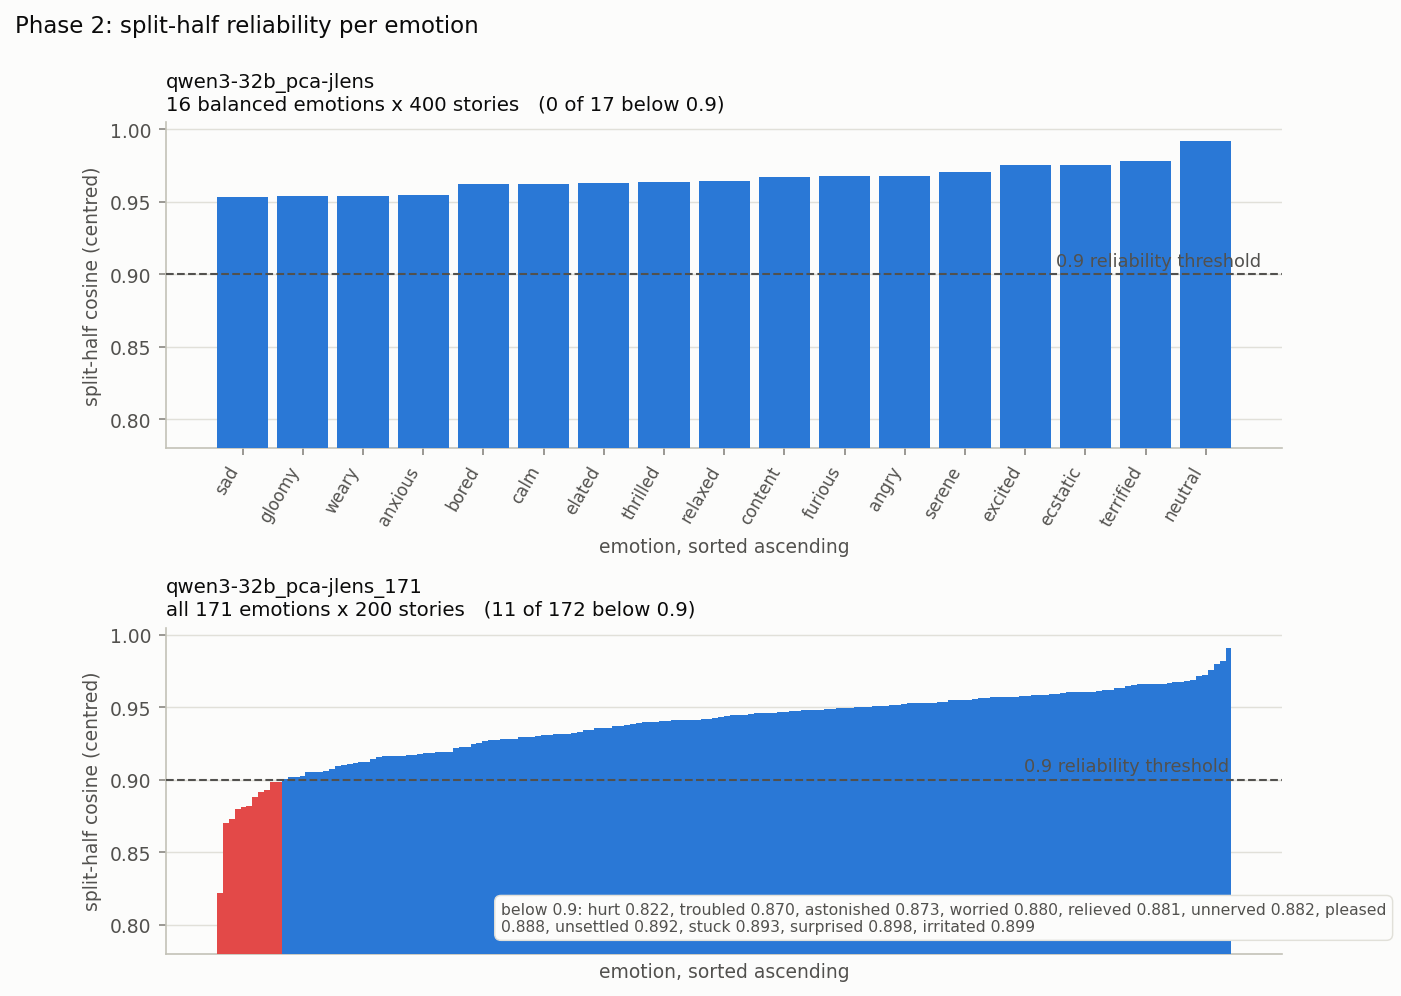

*What it shows.* The 16-emotion run is uniformly reliable: every emotion clears 0.9, minimum 0.954. The 171-emotion run has a real tail — **11 of 172 fall below 0.9**, worst `hurt` at 0.822.

The structure is in the 16 run's weak end: its five weakest are `sad` (LA-N), `gloomy` (LA-N), `weary` (LA-N), `anxious` (HA-N), `bored` (LA-N) — **4 of 5 are the low-arousal-negative quadrant**, which is the whole of LA-N. Sadness, gloom, boredom and weariness produce the least topic-invariant activation of the four quadrants. That is a structured asymmetry, not noise spread evenly across the design.

The raw (uncentred) cosine is ~0.998 in both runs. Reporting that would be meaningless — it measures the shared component of any mean activation, not emotion-specific signal. Everything here uses the centred cosine.

In [5]:
S.phase2()

---

## 4. Phase 3 — PCA over the emotion vectors

The headline claim: PCA over the emotion vectors recovers something like the
valence × arousal circumplex without ever being told about it.

The pipeline's own figures show PC1–PC2. For the 171 run that is the wrong plane, so
this section adds PC2–PC3 and measures how much of the a-priori valence axis actually
lives in each.

## 4. Phase 3 -- PCA

*In plain terms.* *Ask the maths to find the biggest patterns of difference across the emotion fingerprints, without telling it anything about feelings, and see whether it rediscovers the two dimensions psychologists use: pleasant vs unpleasant, and calm vs worked-up.*

### The pipeline's own figures

**Figure 4 -- qwen3-32b_pca-jlens: emotion vectors in the PC1-PC2 plane**

*In plain terms.* A map of all the emotions, placed by the two strongest patterns the maths found on its own, without being told anything about feelings. If those patterns really are pleasantness and intensity, the four kinds of emotion should land in four different corners.

*How to read it.* Each point is one emotion vector projected into the plane of the run's first two principal components. **Fill means arousal, colour means valence**: filled = activated, hollow = deactivated, blue = pleasant, orange = unpleasant. The grey diamond is `neutral`, projected into the plane but held out of the PCA fit. The grey arrows are the a-priori valence and arousal axes projected into this plane, labelled with how much of each axis the plane actually captures — a short arrow means that axis mostly points somewhere else.

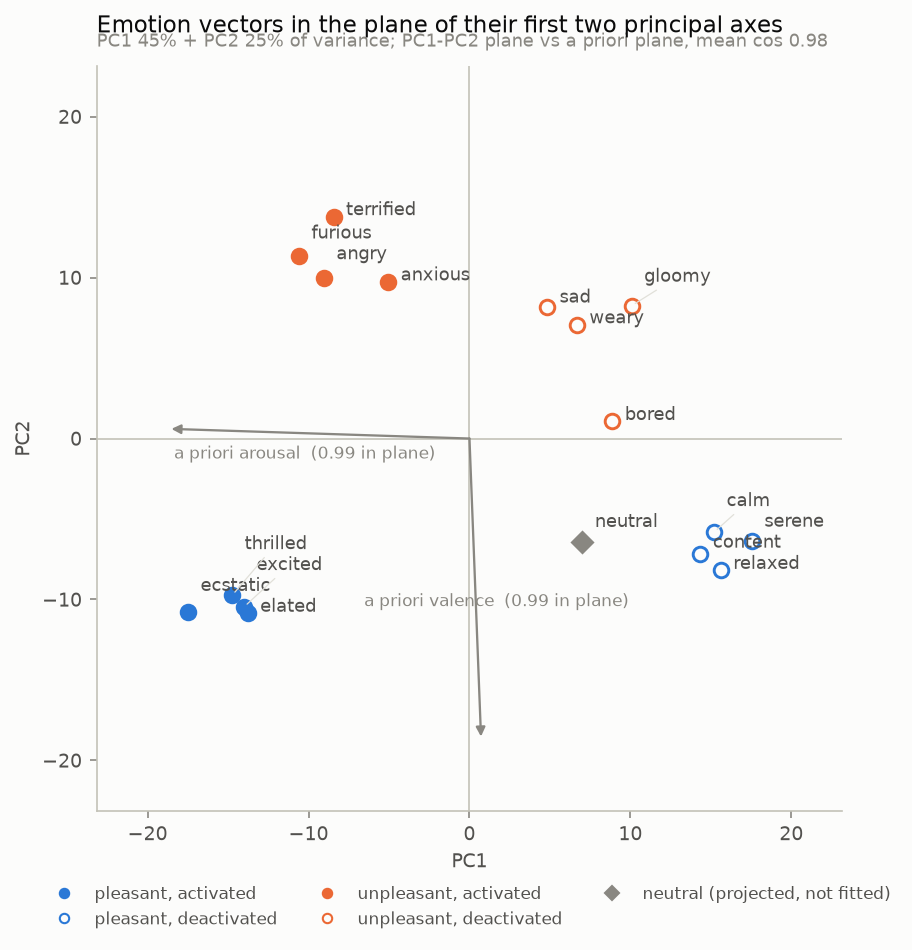

*What it shows.* The four quadrants land in four corners, which is the circumplex recovered without supervision. Both a-priori arrows are long (0.99 in plane), so the plane the PCA found and the plane the labels define are nearly the same plane.

**Figure 5 -- qwen3-32b_pca-jlens: variance explained per PC against the null**

*In plain terms.* How much of the difference between emotions each discovered pattern accounts for, next to how much you would get from patterns found in pure noise. A pattern that does not beat the noise line is not telling you anything.

*How to read it.* Share of total variance carried by each principal component, in descending order, against the isotropic null — the share you would expect from random directions in the same number of dimensions. A PC only means something if it clears that null.

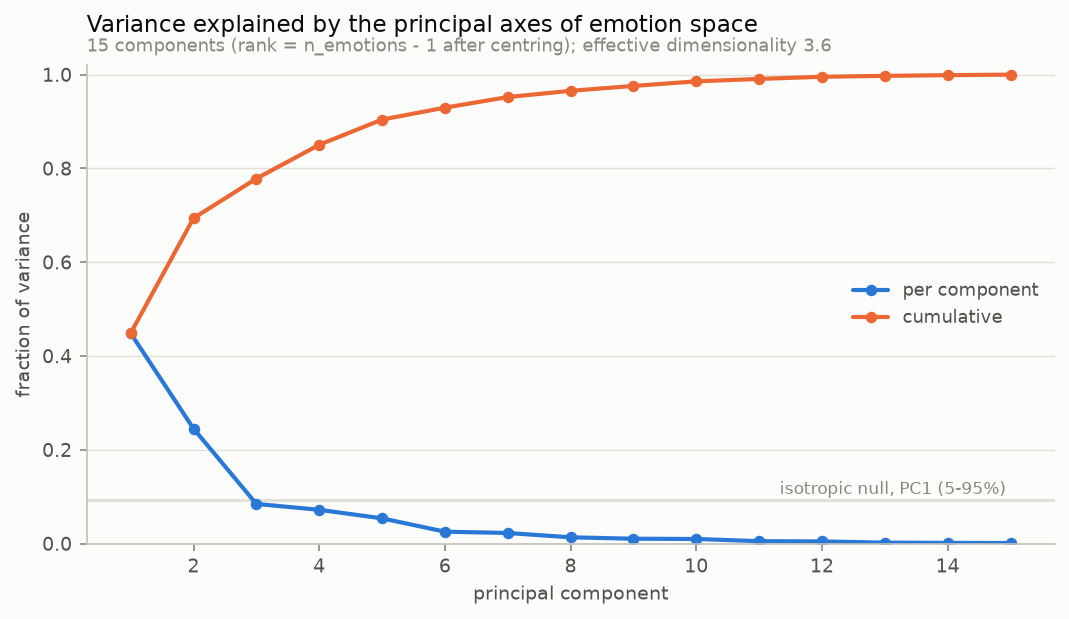

*What it shows.* PC1 and PC2 stand far above the null and far above the rest; the spectrum then falls away. Two components dominate.

**Figure 6 -- qwen3-32b_pca-jlens: per-PC alignment with the a-priori circumplex axes**

*In plain terms.* A grid checking how closely each discovered pattern lines up with the two things psychology says emotions vary on: pleasant vs unpleasant, and worked-up vs calm. Strong colour means a close match; near-white means no relationship.

*How to read it.* A heatmap, one row per PC. The first two columns are the correlation of that PC's *scores* with the anchors' ±1 valence and arousal labels; the last two are the cosine between the PC *direction* and the fitted axis. Red is positive, blue negative, near-white is no relationship. Sign is arbitrary per PC — read magnitude.

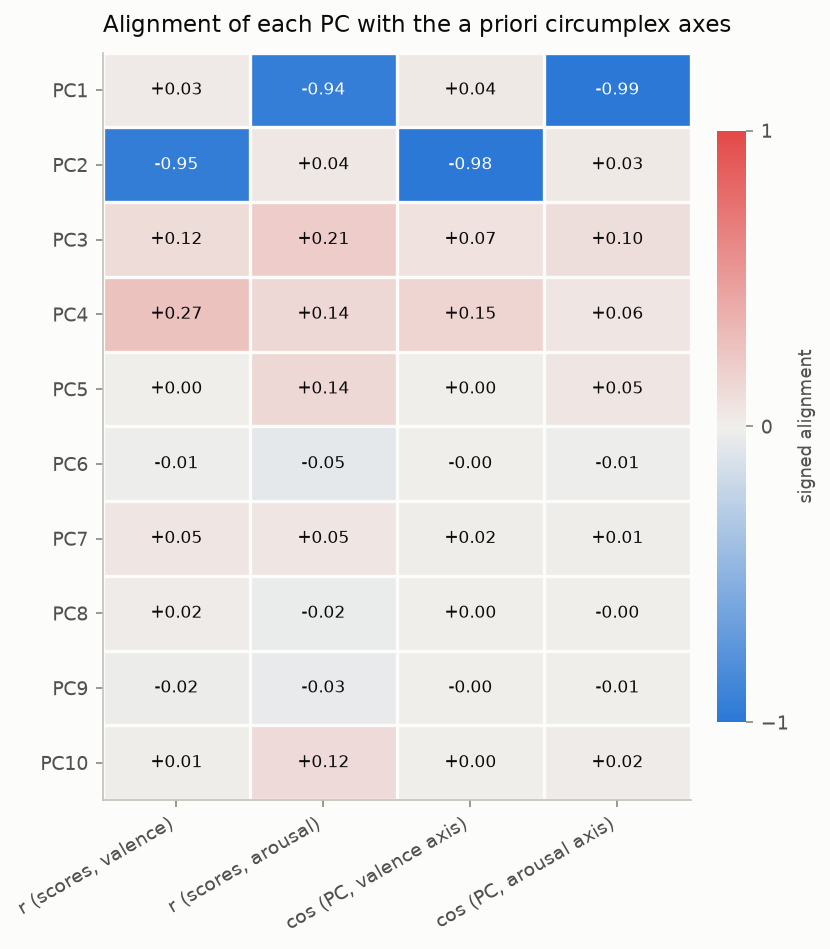

*What it shows.* PC1 is arousal (r = -0.94) and PC2 is valence (r = -0.95), each essentially pure, with everything below PC2 near zero.

**Figure 7 -- qwen3-32b_pca-jlens_171: emotion vectors in the PC1-PC2 plane**

*In plain terms.* A map of all the emotions, placed by the two strongest patterns the maths found on its own, without being told anything about feelings. If those patterns really are pleasantness and intensity, the four kinds of emotion should land in four different corners.

*How to read it.* Each point is one emotion vector projected into the plane of the run's first two principal components. **Fill means arousal, colour means valence**: filled = activated, hollow = deactivated, blue = pleasant, orange = unpleasant. The grey diamond is `neutral`, projected into the plane but held out of the PCA fit. The grey arrows are the a-priori valence and arousal axes projected into this plane, labelled with how much of each axis the plane actually captures — a short arrow means that axis mostly points somewhere else.

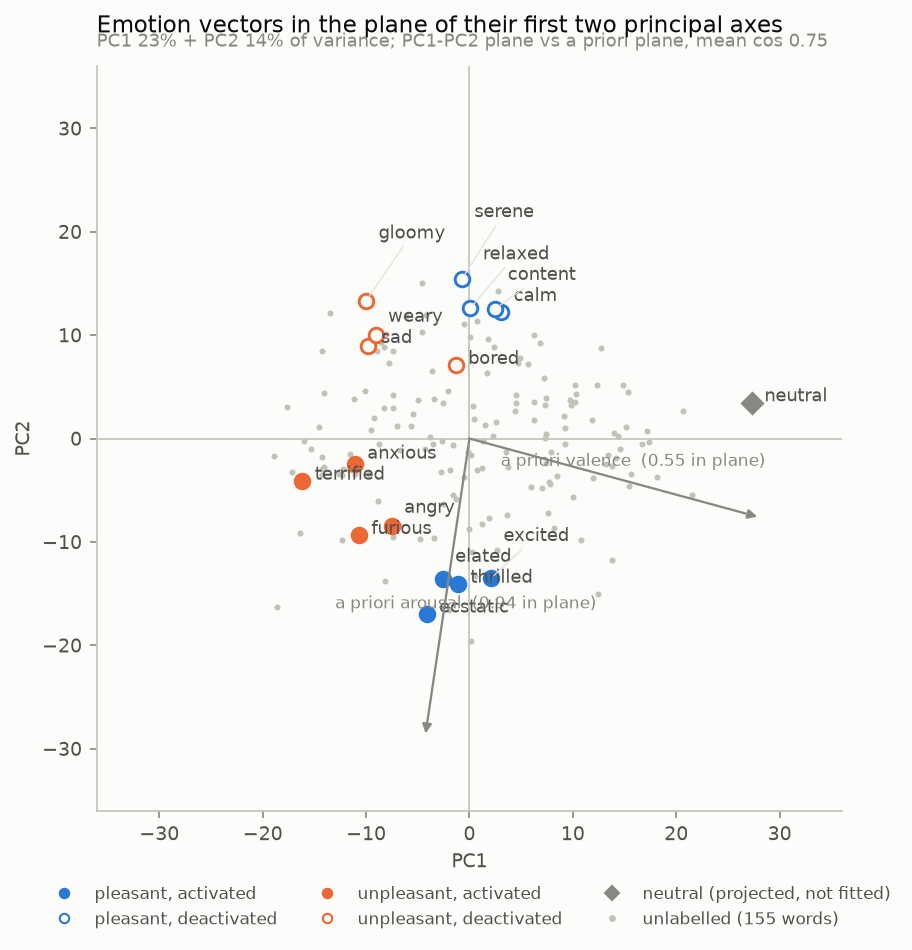

*What it shows.* The anchors do **not** separate cleanly here, and the a-priori valence arrow is visibly short. This figure is the reason the PC2-PC3 scatter below exists: for this run, PC1-PC2 is simply the wrong plane to look at.

**Figure 8 -- qwen3-32b_pca-jlens_171: variance explained per PC against the null**

*In plain terms.* How much of the difference between emotions each discovered pattern accounts for, next to how much you would get from patterns found in pure noise. A pattern that does not beat the noise line is not telling you anything.

*How to read it.* Share of total variance carried by each principal component, in descending order, against the isotropic null — the share you would expect from random directions in the same number of dimensions. A PC only means something if it clears that null.

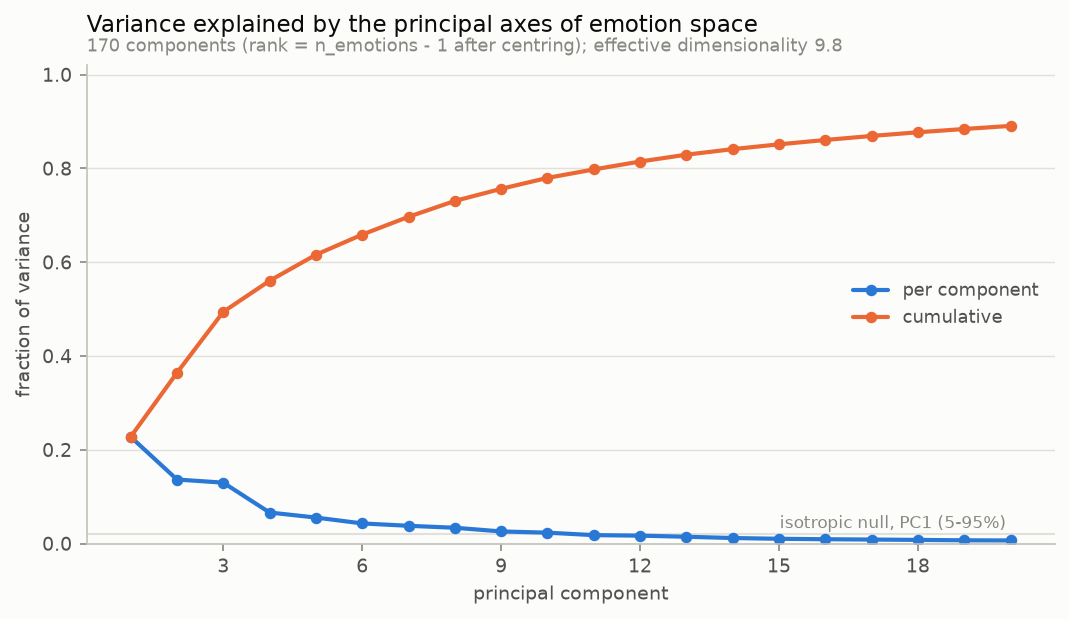

*What it shows.* A much flatter spectrum — PC1 at 23%, and a long tail staying above the null well past PC5. No two components dominate this run.

**Figure 9 -- qwen3-32b_pca-jlens_171: per-PC alignment with the a-priori circumplex axes**

*In plain terms.* A grid checking how closely each discovered pattern lines up with the two things psychology says emotions vary on: pleasant vs unpleasant, and worked-up vs calm. Strong colour means a close match; near-white means no relationship.

*How to read it.* A heatmap, one row per PC. The first two columns are the correlation of that PC's *scores* with the anchors' ±1 valence and arousal labels; the last two are the cosine between the PC *direction* and the fitted axis. Red is positive, blue negative, near-white is no relationship. Sign is arbitrary per PC — read magnitude.

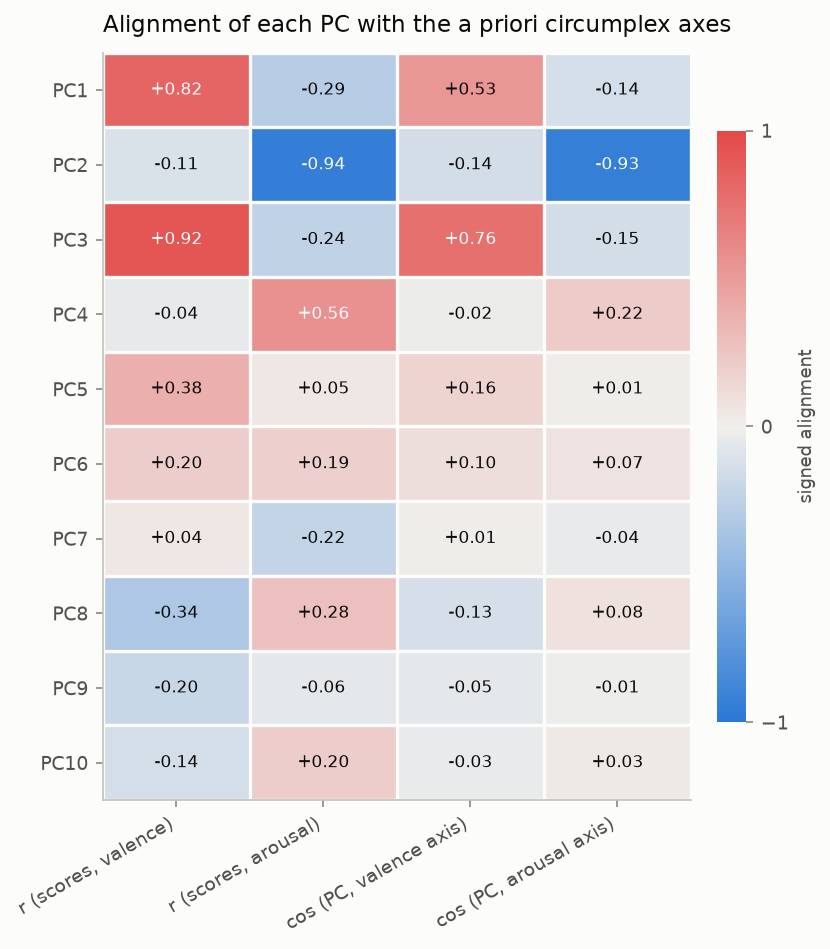

*What it shows.* The strong cells have moved **down one row**: PC2 carries arousal (-0.94) and PC3 carries valence (+0.92). PC1's +0.82 on valence is the contamination diagnosed further down this section.

### Variance and effective dimensionality

**Phase 3 -- variance structure, both runs**

,field,16,171
0,emotions in fit,16,171
1,PCA rank,15,170
2,PC1 variance,0.44861,0.227613
3,PC2 variance,0.24516,0.136602
4,PC3 variance,0.084554,0.129942
5,top-2 cumulative,0.693771,0.364215
6,top-3 cumulative,0.778324,0.494157
7,participation ratio (effective dim),3.594839,9.793057
8,"isotropic null, per-PC p50",0.090992,0.019683
9,PCs stable of 10 (cos > 0.8),8,8


**Phase 3 -- per-PC correlation and cosine with the a-priori axes (r = correlation of PC scores with the +-1 anchor labels; cos = cosine of the PC direction with the fitted axis)**

...

**Phase 3 -- norm of the unit a-priori axis captured by each PC subspace (1.0 = the axis lies entirely inside that subspace)**

,run,valence in PC1-PC2,valence in PC2-PC3,valence in PC1-PC3,arousal in PC1-PC2,arousal in PC2-PC3,arousal in PC1-PC3
0,qwen3-32b_pca-jlens,0.986,0.987,0.988,0.992,0.100,0.997
1,qwen3-32b_pca-jlens_171,0.549,0.772,0.937,0.945,0.946,0.956


**This is why the pipeline's PC1-PC2 figure understates the 171 run.** Only **55%** of the valence axis lies in the PC1-PC2 plane. Moving to PC2-PC3 raises it to **77%**, and the first three PCs together hold **94%**. PC3 carries the valence signal the published scatter cannot show.

### PC2 vs PC3 for the 171-emotion run (new figure)

**Figure 10 -- Phase 3 (new): the 171-emotion run in the PC2-PC3 plane**

*In plain terms.* The same map of emotions as the pipeline's own figure, but drawn along the 2nd and 3rd strongest patterns instead of the 1st and 2nd -- because in the 171-emotion run that is where the pleasant/unpleasant and calm/excited structure actually sits.

*How to read it.* Same encoding as the pipeline's scatter — filled = activated, hollow = deactivated, blue = pleasant, orange = unpleasant — but plotting **PC2 against PC3 instead of PC1 against PC2**. Small grey dots are the 155 emotions with no circumplex labels; they enter the PCA but cannot be scored. The grey diamond is `neutral`, held out of the fit. Arrows are the a-priori axes projected into *this* plane, labelled with the fraction of each axis the plane captures.

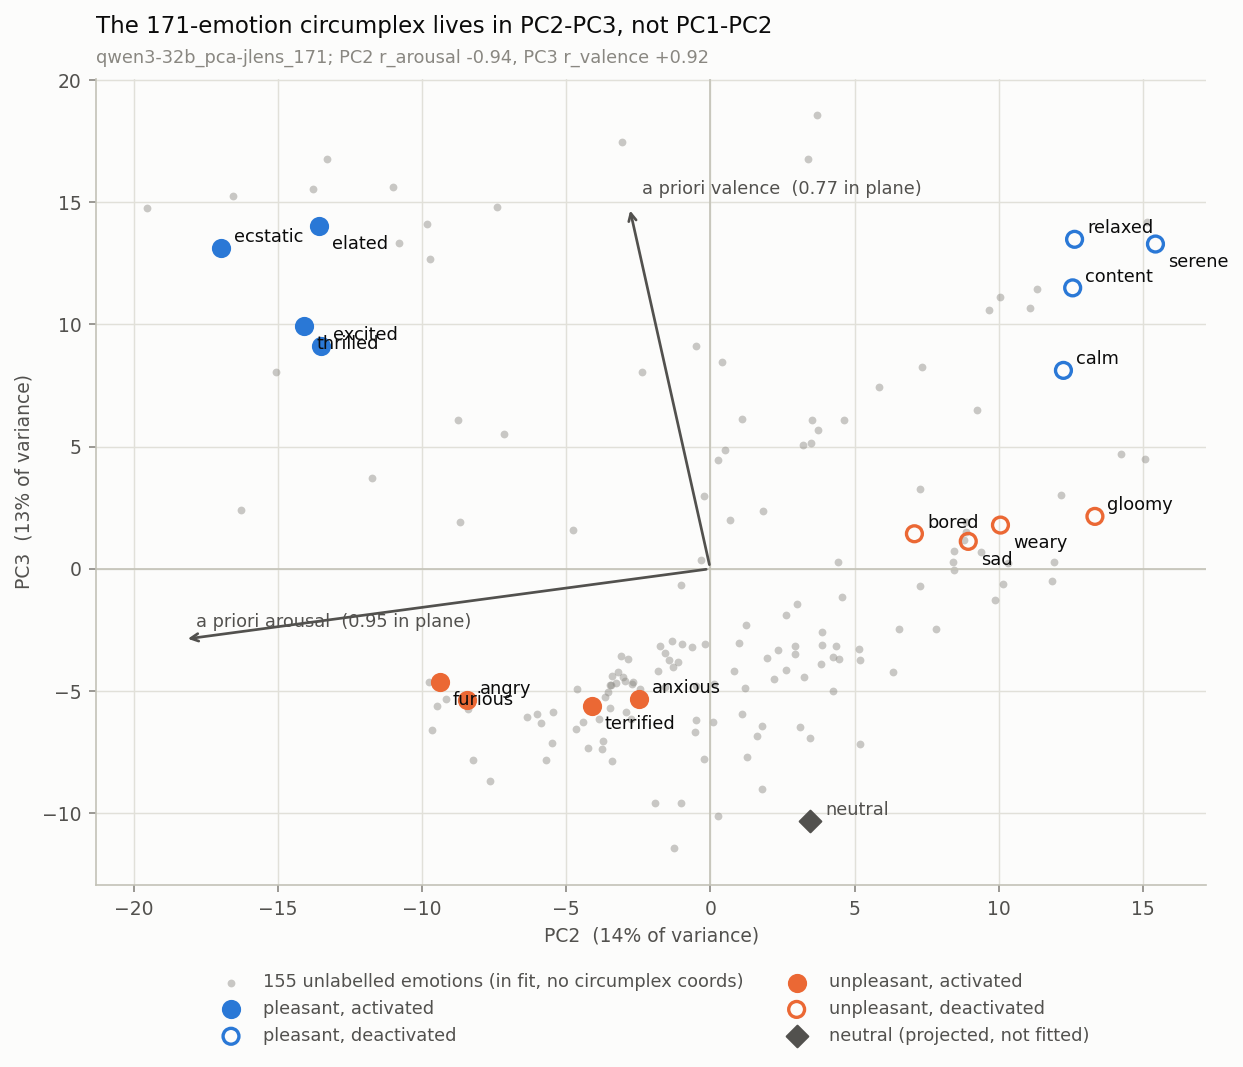

*What it shows.* The circumplex the PC1-PC2 figure could not show. The four anchor groups separate into four regions — pleasant-activated top left, pleasant-deactivated top right, unpleasant-activated bottom left, unpleasant-deactivated middle right — and both arrows are now long (valence 0.77, arousal 0.95 in plane, against 0.55 for valence in PC1-PC2). The 171-emotion run does recover the circumplex; it simply does not put it in the top two components.

### Do the two runs find the same axes?

**Phase 3 -- absolute cosine between the two runs' principal axes**

,abs cosine,171-run PC1,171-run PC2,171-run PC3,171-run PC4,171-run PC5
0,16-run PC1,0.146,0.927,0.099,0.205,0.046
1,16-run PC2,0.535,0.183,0.765,0.088,0.110
2,16-run PC3,0.259,0.237,0.175,0.183,0.067
3,16-run PC4,0.215,0.070,0.180,0.649,0.294
4,16-run PC5,0.076,0.047,0.272,0.105,0.744


**Phase 3 -- the a-priori axes are the same in both runs (both fitted from the same 16 anchors)**

...

### What PC1 of the 171 run actually is

**Phase 3 -- diagnosing PC1 of the 171-emotion run**

,quantity,value
0,PC1 range over the 171 fitted emotions,-18.9 .. 21.5
1,PC1 score of `neutral` (held OUT of the fit),+27.3
2,8 lowest on PC1,"tormented, hysterical, disoriented, distressed, panicked, terrified, shaken, overwhelmed"
3,8 highest on PC1,"greedy, kind, vindictive, smug, self-confident, optimistic, vengeful, spiteful"
4,"corr(PC1 score, vector norm)",+0.29


**Reading.** PC1 of the 171 run is not a circumplex axis. Its low end is `tormented`, `hysterical`, `disoriented`, `distressed`, `panicked` — overwhelming, high-intensity affect — and its high end is `greedy`, `kind`, `vindictive`, `smug`, `self-confident` — appraisal-like, dispositional or motivational states rather than acute affect. Decisively: **`neutral`, held out of the PCA fit entirely, projects to PC1 = +27.3, beyond the +21.5 maximum of all 171 fitted emotions.** PC1 is substantially an *affect-presence / intensity* axis, with the absence of affect at the extreme. It correlates with valence (r = +0.82) only because intense states in this vocabulary skew unpleasant. This is what pushes the circumplex down into PC2-PC3.

**Reading — Phase 3 overall.**

* **qwen3-32b_pca-jlens** — top-2 PCs hold 69% of variance against an isotropic null of 13.3%. Participation ratio **3.59**. Best valence PC = PC2, best arousal PC = PC1. Plane principal cosines 1.00, 0.95 (mean 0.98). Cross-fit worst plane angle 20.2 deg. `axes_identified = True`, `plane_stable = True`.
* **qwen3-32b_pca-jlens_171** — top-2 PCs hold 36% of variance against an isotropic null of 1.2%. Participation ratio **9.79**. Best valence PC = PC3, best arousal PC = PC2. Plane principal cosines 0.95, 0.54 (mean 0.75). Cross-fit worst plane angle 62.2 deg. `axes_identified = False`, `plane_stable = False`.

The 16-emotion run recovers the circumplex cleanly and the gate says so. The 171-emotion run recovers the *same two directions* — the cross-run cosines above — but they are no longer the top two, they hold far less variance, and Phase 3's own stability check marks the top-2 plane as **not** stable and the axes as **not** identified. A participation ratio of 9.8 is the honest headline for the 171 run: the circumplex is a 2-D slice of a roughly 10-dimensional space, not a description of it.

In [6]:
S.phase3()

---

## 5. Phase 4 — reading the PCs through the lens

Phase 4's artefacts are the hardest to read: `phase4_gate.json` is 73 KB / 157 KB and
`phase4_readouts.csv` carries 360 / 2,220 token rows, most of it the per-emotion GATE A
readout that nobody can read as a listing.

The readable form is three views and one number: **one verdict row per PC**; **token
panels for the top 3 PCs only**, `+` and `−` adjacent so antonymy can be judged; **AUROC
as a figure**, since that is what is comparable across PCs and runs; and the 2,052-row
GATE A block collapsed to a **script-mix percentage**.

Sections 5e–5i then deal with the Chinese directly.

Tokens stay in tables and never in figures — matplotlib's default font renders CJK as
tofu boxes.

## 5. Phase 4 -- lens readouts of the PCs

*In plain terms.* *Take the patterns the maths discovered and ask the lens what words they correspond to. This is where the model turns out to answer in Chinese, which breaks a test that was written expecting English.*

### 5a. Verdict per PC

**Phase 4 GATE B -- verdict per PC, qwen3-32b_pca-jlens (16 balanced emotions x 400 stories)**

,PC,variance,verdict,best axis,"AUROC (best end, best axis)",p (best axis),alpha,sig. at alpha,PC stability (Phase 3),sign agrees with Phase 3
0,1,0.448610,reads as AROUSAL,arousal,0.979592,0.002999,0.050000,True,0.989710,True
1,2,0.245160,reads as VALENCE,valence,1.000000,0.001499,0.050000,True,0.988064,True
2,3,0.084554,MURKY,valence,0.653061,0.369815,0.008333,False,0.931159,None
3,4,0.072003,MURKY,arousal,0.734694,0.168916,0.008333,False,0.910282,None
4,5,0.053806,MURKY,arousal,0.591837,0.624688,0.008333,False,0.934035,None


...

**Phase 4 -- control: the a-priori valence/arousal axes read through the same lens, qwen3-32b_pca-jlens_171**

,axis,AUROC valence,AUROC arousal,effective tokens,top 12 tokens
0,+valence,1.000,0.531,35.920,`欢快` `甜美` `甜蜜` `庆典` `可爱` `美妙` `可爱的` `愉快` `活泼` `美味` `优雅` `欢呼`
1,-valence,0.000,0.469,77.798,`失败` ` failed` ` Worse` `拒绝` ` failure` `缺乏` `无力` ` worse` `绝望` `崩溃` ` failing` `死亡`
2,+arousal,0.347,0.959,9.322,`疯狂` `暴涨` `迅猛` ` Prostitutas` `狠狠` `震惊` `扫黑除恶` `引爆` `火爆` `爆炸` ` pornost` `尖叫`
3,-arousal,0.653,0.020,2.175,` \n` ` \n` `.` `.\n` `\xa0` ` ` ` \n` ` \n\n` `温和` `\n` `偶尔` `~\n`


**Reading the antonym question honestly.** The two ends of a PC are exact negations by construction, so *that* they order the anchors oppositely is arithmetic, not evidence. The only non-arithmetic question is whether the token lists read as antonyms — judged by eye from the tables above, which is why they are printed in full. Two things are measurable rather than impressionistic:

* Several ends are dominated by **whitespace and punctuation**. The `+PC1` end of the 16 run puts 0.90 probability on `' \n'` with an effective token count under 2 — that end is one newline, and cannot be judged for antonymy at all.
* The content-bearing ends are overwhelmingly Chinese. That is quantified next.

### 5c. AUROC per PC per end

**Figure 11 -- Phase 4 (new): AUROC of each PC end against each circumplex axis, both runs**

*In plain terms.* Each pattern the maths found is a direction with two ends. This asks whether either end can correctly sort the emotions from pleasant to unpleasant, or from calm to worked-up. 1.0 is a perfect sort; 0.5 is no better than guessing.

*How to read it.* Four panels: rows are the two runs, columns are the two circumplex axes. Within a panel each PC gets two bars — its `+` end (blue) and its `-` end (orange). AUROC asks: **does this end of this PC rank the pleasant (or activated) anchors above the others?** 1.0 is perfect, 0.5 is chance, 0.0 is perfectly inverted. Because the two ends are exact complements, **each pair of bars sums to 1.00 by construction** — read which end carries the ordering, not two independent measurements. Dashed line is the 0.75 pass threshold; solid line is chance.

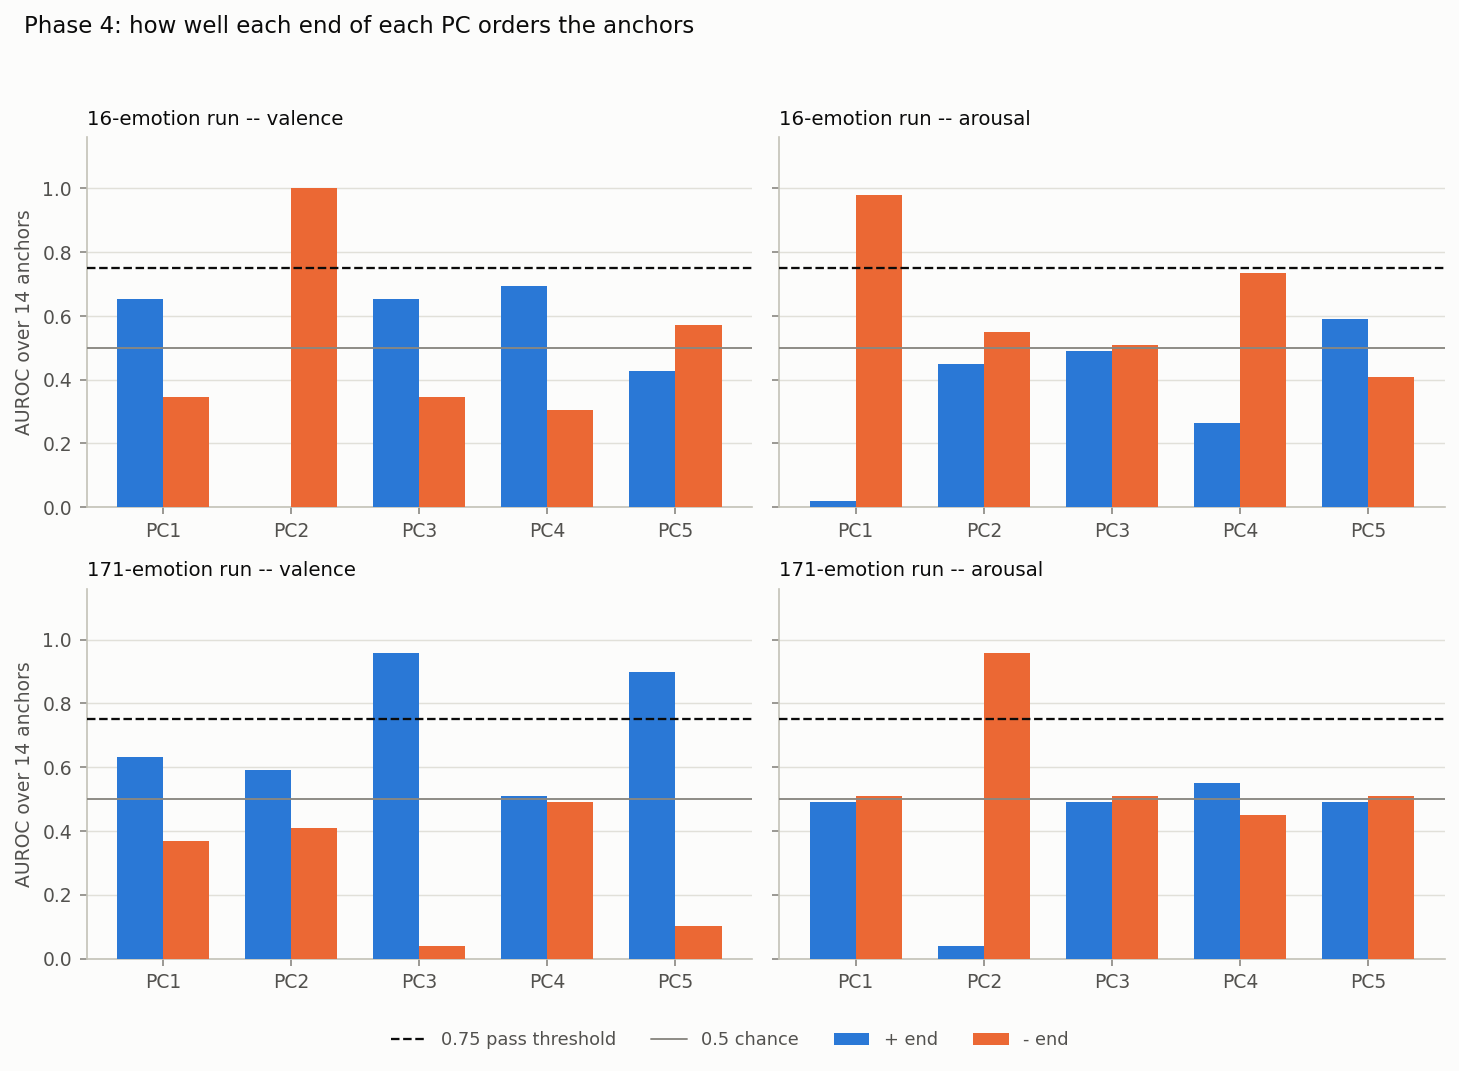

*What it shows.* **5 of the 20 (PC, axis) cells clear 0.75, and 4 of those also clear their own alpha.** In the 16 run it is PC1 on arousal and PC2 on valence; in the 171 run it is PC2 on arousal and PC3 on valence — the same one-slot shift the cross-run cosines showed. Everything else sits against the chance line.

The exception worth naming is the 171 run's **PC5 on valence: AUROC 0.90 at p = 0.012**. It clears the AUROC bar and would be significant at 0.05, but PC5 is exploratory and its threshold is 0.0083 over six tests, where roughly one hit at p < 0.05 is expected by chance. The pipeline does not interpret it and neither does this notebook.

**Phase 4 -- every PC end that clears AUROC 0.75, and whether it also clears its own significance threshold**

,run,PC,axis,end,AUROC,p,alpha,significant at its alpha
0,16,1,arousal,-,0.979592,0.002999,0.050000,True
1,16,2,valence,-,1.000000,0.001499,0.050000,True
2,171,2,arousal,-,0.959184,0.003498,0.050000,True
3,171,3,valence,+,0.959184,0.002499,0.008333,True
4,171,5,valence,+,0.897959,0.011994,0.008333,False


### 5d. What script are the readouts in?

**Phase 4 -- script of the top-12 tokens per readout, as a percentage of all tokens in that group**

,run,readout group,n directions,n tokens,CJK,Latin,other script,punct / whitespace
0,16,a-priori axis controls,4,48,64.6,14.6,0.0,20.8
1,16,emotion vectors (GATE A),16,192,60.9,14.1,5.7,19.3
2,16,PC ends (GATE B),10,120,42.5,40.0,2.5,15.0
3,171,a-priori axis controls,4,48,64.6,14.6,0.0,20.8
4,171,emotion vectors (GATE A),171,2052,42.0,32.9,3.0,22.1
5,171,PC ends (GATE B),10,120,44.2,25.0,7.5,23.3


**Phase 4 -- script mix over every readout in the run**

,run,"all readouts, n tokens",CJK %,Latin %,other script %,punct / whitespace %
0,qwen3-32b_pca-jlens,360,55.3,22.8,3.9,18.1
1,qwen3-32b_pca-jlens_171,2220,42.6,32.1,3.2,22.1


**Phase 4 GATE A -- does an emotion vector's lens readout contain its own English word? (aggregate; the 2,052 individual token rows are in `phase4_readouts.csv`)**

field,field,qwen3-32b_pca-jlens,qwen3-32b_pca-jlens_171
0,emotions scorable (single-token),14,114
1,"untokenizable, excluded",2,57
2,HIT,0,5
3,near,3,20
4,hit rate,0.0,0.04386
5,threshold to pass,0.5,0.5
6,passed,False,False
7,chance hit rate,0.000079,0.000079
8,median rank of the emotion's own word,363.0,950.5
9,% of top-12 tokens that are CJK,60.9,42.0


In [7]:
S.phase4_readouts()

### The readouts are in Chinese — what follows

Sections 5e–5i separate two causes that GATE A's failure conflates, gloss the tokens so
the evidence can be read without Chinese, and re-score the gate under three definitions
of "the emotion's name".

`analysis/zh_en_glossary.py` holds the hand-written data these need. It is **not
pipeline output** — read its docstring for the pre-commitment protocol and disclosed
contamination before trusting section 5f.

### Why the readouts are Chinese, and the two confounds that hides

Qwen3-32B is bilingual, so "the readouts are Chinese because it is a Chinese model" is the obvious reading. It is not sufficient: **96-97% of the Latin tokens in these readouts are whole words** (` failed`, ` sorrow`, ` panic`), not subword fragments. The lens is not being pushed into Chinese because English tokenises badly -- it selects dense whole words when it selects Latin at all, and still prefers Chinese for content. The stimuli, the anchors and the probe words are all English.

That makes GATE A's failure ambiguous between **two separate causes**, which need different fixes:

1. **Script.** The direction names its concept in Chinese, so no English lemma can reach the top-12 however good the direction is.
2. **Exact-lemma matching.** The readout offers ` sorrow` where the test demands ` sad`. A near-synonym is not a hit.

Translating the output addresses only the first. What follows scores them separately: a Chinese tier for the script confound, an English near-synonym tier for the lemma confound, tokenizer-checked denominators in 5h, and 5g explaining why Phase 4's *other* test -- the AUROC ordering statistic -- was immune to both.

The hand-written data is in `analysis/zh_en_glossary.py`. It is **not pipeline output**: it is a human translation judgement, written from the emotion words alone and saved before any matching was run, kept in its own module so it can be audited separately.

### 5e. Every lensed direction, with translations

qwen3-32b_pca-jlens: 360 rows, 216/216 non-Latin tokens glossed
qwen3-32b_pca-jlens_171: 2220 rows, 1020/1020 non-Latin tokens glossed


**Phase 4 -- every lensed principal component, both poles, qwen3-32b_pca-jlens. Translations from `phase4_readouts_translated.csv`; `effective tokens` is exp(entropy) over the whole vocabulary**

,PC,pole,variance,PC verdict,AUROC valence,AUROC arousal,top-1 prob,effective tokens,top-12 mass,interpretable?,top-12 tokens (translated)
0,1,+,0.448610,reads as arousal,0.653061,0.020408,0.897619,1.757160,0.988172,yes,"` \n` · ` \n` · `.` · `.\n` · ` \n` · ` ` · `\xa0` · ` \n\n` · **mild, gentle** · `~\n` · `\n` · **LEFT-TO-RIGHT MARK: invisible bidi control, no lexical content**"
1,1,-,0.448610,reads as arousal,0.346939,0.959184,0.642702,7.132749,0.902800,yes,"**crazy, frenzied** · **surge, soar sharply** · **swift and fierce** · **fiercely, ruthlessly** · **prostitutes (Spanish, Portuguese)** · **shocked, stunned** · **explosive, hot-tempered, booming** · **detonate, set ..."
2,2,+,0.245160,reads as valence,0.000000,0.448980,0.123589,251.219279,0.452493,top-12 is an arbitrary slice,"` failed` · **failure, to fail** · ` failure` · ` Worse` · ` lack` · ` failing` · **refuse, reject** · **powerless, weak** · **lack, deficiency** · **despair, hopeless** · ` worse` · **death**"
3,2,-,0.245160,reads as valence,0.979592,0.591837,0.269085,52.310591,0.685455,yes,"**cheerful, lively** · **sweet, lovely** · **celebration, ceremony** · **sweet (affectionate)** · **cute, lovable** · **cute (attributive form)** · **wonderful, marvellous** · **pleasant, cheerful** · **cheer, acclai..."
4,3,+,0.084554,MURKY,0.653061,0.489796,0.191094,221.851565,0.486216,top-12 is an arbitrary slice,"**erotica, erotic (German, Turkish, Scandinavian)** · **strap-on (sex toy)** · **sluts (French, vulgar)** · **murderer** · **escort (Scandinavian, Turkish)** · **naughty girl, minx (French)** · **executioner (bound m..."
5,3,-,0.084554,MURKY,0.265306,0.489796,0.187945,83.997945,0.577480,yes,"**sadness, sorrow** · ` sadness` · **fall ill** · ` maybe` · ` feeling` · ` dreams` · ` something` · **depression (clinical)** · ` somehow` · ` hope` · ` things` · **anxious, exhausted (rare classical char)**"
6,4,+,0.072003,MURKY,0.693878,0.265306,0.609131,24.783601,0.716896,yes,`.\n` · ` heart` · ` \n` · ` deeply` · ` warmth` · ` \n` · `.` · ` delicate` · ` nature` · ` enduring` · ` emotional` · ` journey`
7,4,-,0.072003,MURKY,0.265306,0.612245,0.397050,28.983643,0.760118,yes,"**fragment of pornostar(s) / pornoster; porn-spam vocabulary** · **fetish (German, Dutch)** · **bound char of 噱头 'gimmick, sales hook'** · **to have no money** · **bored; boring, tedious** · **funny, comedic** · **to..."
8,5,+,0.053806,MURKY,0.428571,0.591837,0.071228,1117.419592,0.300906,top-12 is an arbitrary slice,"**erotica, erotic (German, Turkish, Scandinavian)** · **fragment of Почему 'why' (or почем 'how much')** · **stem of практика / практический 'practice, practical'** · **to investigate (a crime)** · **Polish fragment,..."
9,5,-,0.053806,MURKY,0.346939,0.408163,0.123805,211.666705,0.429867,top-12 is an arbitrary slice,` countless` · ` pride` · ` beloved` · ` proud` · ` sorrow` · **'...'s power' (的 + 强大 'powerful')** · ` weary` · ` glory` · ` mighty` · ` merciless` · ` joy` · ` immortal`


...

**Phase 4 -- GATE A re-scored in three tiers, qwen3-32b_pca-jlens. Each tier asks the same containment question GATE A asks (is it in the top-12?), varying only what counts as the emotion's name**

,tier,hits / all emotions,rate (all),rate (English-single-token subset),wrong-emotion list rate,permutation null mean,permutation null p95,p
0,T1 exact English lemma (= GATE A as specified),0/16,0.0000,0.000000,NaN,NaN,NaN,NaN
1,T2 English near-synonym,1/16,0.0625,0.071429,0.000000,0.003938,0.0625,0.063468
2,T3 Chinese translation,10/16,0.6250,0.714286,0.079167,0.114500,0.2500,0.000500


**Phase 4 -- GATE A re-scored in three tiers, qwen3-32b_pca-jlens_171. Each tier asks the same containment question GATE A asks (is it in the top-12?), varying only what counts as the emotion's name**

,tier,hits / all emotions,rate (all),rate (English-single-token subset),wrong-emotion list rate,permutation null mean,permutation null p95,p
3,T1 exact English lemma (= GATE A as specified),5/171,0.029240,0.043860,NaN,NaN,NaN,NaN
4,T2 English near-synonym,13/171,0.076023,0.087719,0.004162,0.004643,0.011696,0.0005
5,T3 Chinese translation,43/171,0.251462,0.289474,0.015893,0.017550,0.035088,0.0005


**Figure 12 -- Phase 4 (new): GATE A re-scored by what counts as the emotion's name**

*In plain terms.* When we ask an emotion's direction what word it is, does its own name come back? This tries three definitions of 'its name' -- the exact English word, an English near-synonym, and a Chinese translation -- to find out whether the original test failed because the direction is meaningless or because we asked in the wrong language.

*How to read it.* One panel per run, three bars each. Every bar answers the **same** question GATE A asks — *is the emotion's name inside its vector's top-12 lens tokens?* — varying only what counts as a name: T1 the exact English lemma (GATE A as specified), T2 an English near-synonym, T3 a Chinese translation. The **orange rule over each bar is the 95th percentile of a permutation null** that shuffles the translation lists between emotions, keeping every list's contents and length intact: a bar must clear its orange rule to mean anything at all. The dashed line is GATE A's own 50% pass bar.

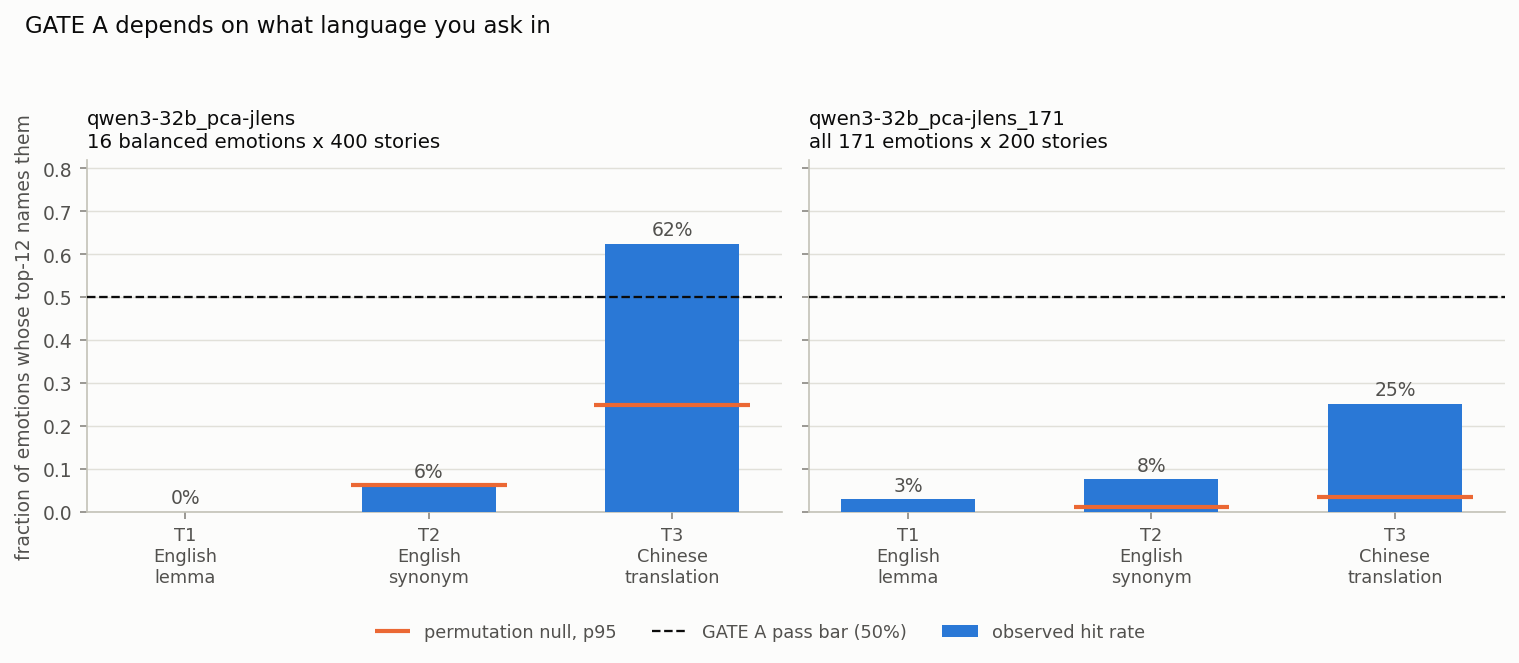

*What it shows.* Scored on the English lemma the directions look unreadable (0% and 3%). Scored on Chinese translations with the identical containment rule, the 16 run reaches **62%** and the 171 run **25%** — the 16 run clearing GATE A's own pass bar.

**The lists are not doing the work**, which is what the orange rules establish. Chance under the permutation null is 11% and 2% (p = 0.0005, 0.0005, 2000 permutations). T2 clears its null on the 171 run but not the 16 run, where a single hit at n = 16 is underpowered — so exact-lemma matching costs something, but script is much the larger effect.

**What this changes, and what it does not.**

GATE A's premise — that a direction the lens can read should surface the emotion's name — is largely satisfied; the test asked in the wrong language. But:

* The pipeline's recorded GATE A verdict **stands as FAILED**. This is a re-scoring under a hand-written translation table, not a re-run of the gate, and it is reported as a secondary result rather than substituted for the original.
* It is a **containment** test, not a rank test. The readout CSVs store only the top 12, so there is no Chinese analogue of `own_word_rank`.
* Denominators differ by tier. T1 can only score English-single-token emotions; T3 can score `elated` and `gloomy` too, because their Chinese forms tokenise when the English does not. Both denominators are in the table; 5h checks them against the real tokenizer.
* The translations are the author's judgement — pre-committed and permutation-controlled, but a reader who disagrees with `serene -> 柔和` or `ecstatic -> 狂欢` should re-score with their own list.
* The under-converged lens (section 0) is untouched by any of this.

**Phase 4 -- every emotion scored as a hit in the relaxed tiers, with the exact tokens that matched (audit trail)**

,run,emotion,Chinese tokens matched,English tokens matched
0,16,angry,愤怒,
1,16,bored,无聊,
2,16,calm,温和,
3,16,ecstatic,狂欢,
4,16,furious,愤怒,
5,16,relaxed,悠闲 放松,
6,16,sad,伤心,sorrow
7,16,serene,柔和,
8,16,terrified,恐惧 害怕,
9,16,thrilled,狂欢,


**The full pre-committed translation table used above, all 171 emotions. Published so the generosity of the matching can be audited and re-scored**

,emotion,Chinese candidates,English near-synonyms
0,afraid,害怕 恐惧 畏惧 惧怕,"fear, fears, feared, fearful, scared, frightened, terror, dread"
1,alarmed,警觉 惊慌 警报 震惊,"alarm, alarming, startled, panic"
2,alert,警觉 警惕 警报 提醒,"alertness, vigilant, watchful, warning"
3,amazed,惊讶 惊奇 震惊 惊叹,"amazing, amazement, astonished, wonder, awe"
4,amused,有趣 好笑 逗乐 娱乐,"amusing, amusement, funny, laugh, humor"
...,...,...,...
166,vulnerable,脆弱 无助 易受伤害,"vulnerability, fragile, defenseless, exposed"
167,weary,疲惫 疲倦 厌倦 疲劳,"weariness, tired, fatigue, exhausted, worn"
168,worn out,疲惫 精疲力尽 磨损 累,"worn, exhausted, tired, spent, depleted"
169,worried,担心 忧虑 焦虑 担忧,"worry, worrying, anxious, concerned, apprehensive"


### 5g. Why GATE B survived what GATE A did not

**Phase 4 -- where the English probe words actually rank in the a-priori axis readouts (16-emotion run)**

,a-priori axis,AUROC on its own axis,"median rank, pleasant","median rank, unpleasant",separation is perfect,best rank of ANY probe word,probes inside GATE A's top-12 window,"median rank, activated","median rank, deactivated"
0,+valence,1.000000,5672.0,127269.0,True,1927,0,NaN,NaN
1,+arousal,0.959184,NaN,NaN,False,258,0,3872.0,140013.0


**Figure 13 -- Phase 4 (new): rank of each English probe word in the a-priori axis readouts**

*In plain terms.* Where do the English emotion words actually show up in what a direction wants to say? Far left means the lens is eager to say that word; far right means 150,000 other things come out first.

*How to read it.* Each dot is one English probe word, placed at **its rank in that direction's readout** — a log scale, so far left means 'the lens wants to say this word' and far right means 'the lens has 150,000 other things to say first'. Colour is the pole the word belongs to. The dashed line at rank 12 is GATE A's window: only a dot left of it could ever count as a GATE A hit. The grey line at the right is the full vocabulary size.

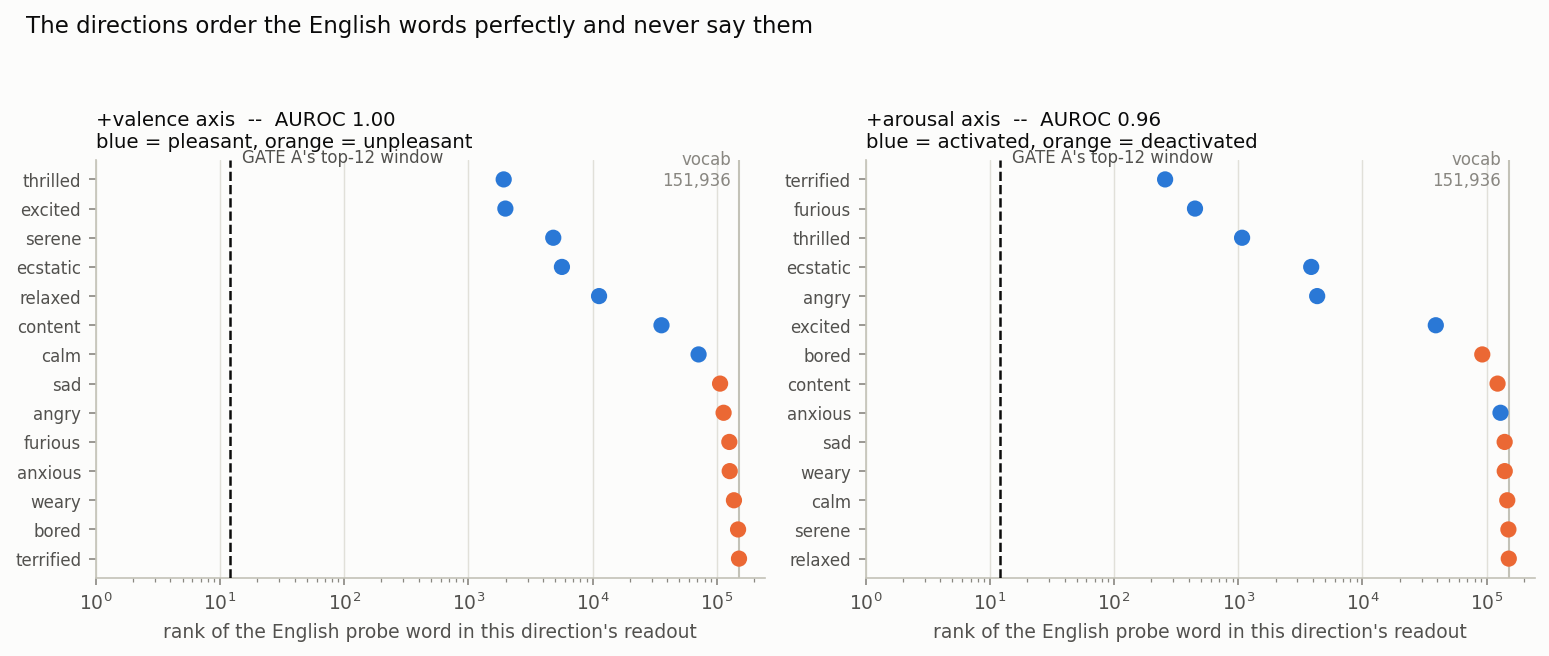

*What it shows.* Two facts at once, and their combination is the point. **The colours separate completely** — every pleasant word ranks above every unpleasant one, which is what AUROC 1.00 means. **And every dot is far right of the dashed line** — the best-ranked English emotion word sits at 1,927 of 151,936, and not one is inside GATE A's window.

So the two Phase 4 tests were never measuring the same thing. **GATE A is an absolute containment test** and is destroyed by the readout preferring another language, because the top-12 fills with Chinese before any English word gets near it. **AUROC is a relative test within a fixed probe set** — it never asks whether English words rank *highly*, only whether the pleasant ones rank *above* the unpleasant ones, and burying all fourteen by a common factor leaves that untouched.

The direction knows about valence in English. It just does not *say* it in English. That single claim explains why GATE A failed, GATE B passed at 0.98–1.00, and the Chinese re-scoring in 5f recovers the naming behaviour GATE A was looking for.

### 5h. Tokenizer-checked denominators (fully local)

tokenizer: data/hf_cache/models--Qwen--Qwen3-32B/snapshots/9216db5781bf21249d130ec9da846c4624c16137/tokenizer.json | vocab 151669


**Phase 4 -- denominators checked against the real Qwen3-32B tokenizer, computed locally with no model and no network**

,run,emotions in run,scorable in English (single-token lemma),NOT scorable in English,testable in Chinese (>=1 single-token form),"of those, invisible to English GATE A","T3 rate, naive denominator (all emotions)","T3 rate, honest denominator (Chinese-testable)"
0,16,16,14,2,16,2,0.625000,0.625000
1,171,171,114,57,152,43,0.251462,0.282895


**Why this matters, and why it needed no GPU.** Section 5f rested on an assumption it could not check: that the Chinese candidates are single tokens in Qwen's vocabulary. Only **59%** of the 606 are. A multi-token candidate can never appear in a top-12 *token* list, so it silently deflates the hit rate. The Qwen3-32B **tokenizer** is cached locally at 11 MB and carries no weights, so this is pure local computation.

* **The honest denominator is the Chinese-testable set.** 19 emotions have no single-token Chinese form at all (`ashamed`, `contemptuous`, `droopy`, `euphoric`, `exasperated`, `grumpy`, `hostile`, `humiliated`, ...) and cannot be scored by the Chinese tier any more than `elated` can be scored by the English one.
* **GATE A structurally could not score a third of the 171-emotion run.** 57 of 171 emotions have no single-token English lemma, and **43 of those 57 do have a single-token Chinese form**. Their exclusion has nothing to do with whether their direction is readable — English simply spells them with more than one token.

This is a rigour fix, not a rescue: it moves the Chinese-tier rate by a few points and leaves 5f's permutation-controlled conclusion where it was.

In [8]:
S.phase4_chinese()

### 5j. Does the shape of the readout distribution matter?

**Phase 4 -- how concentrated each readout is, qwen3-32b_pca-jlens. `effective_tokens = exp(entropy)` over the whole vocabulary; the summary column is the author's reading of the glossed tokens, not a measurement**

,family,direction,top-1 prob,effective_tokens,top-12 mass,whitespace end,author's one-line summary
0,PC1,+PC1,0.897619,1.757160,0.988172,True,"formatting: newlines and spaces, no semantic content (温和 mild is the only word)"
13,a-priori axis,-arousal,0.884615,1.996716,0.981302,True,
1,PC1,-PC1,0.642702,7.132749,0.902800,False,"violent, explosive high-intensity action -- frenzy, detonation, screaming"
12,a-priori axis,+arousal,0.589750,8.178891,0.901819,False,
6,PC4,+PC4,0.609131,24.783601,0.716896,False,not interpreted -- MURKY on both axes
7,PC4,-PC4,0.397050,28.983643,0.760118,False,not interpreted -- MURKY on both axes
10,a-priori axis,+valence,0.271265,39.134609,0.721637,False,
3,PC2,-PC2,0.269085,52.310591,0.685455,False,"sweetness and celebration -- cheerful, sweet, cute, delightful"
5,PC3,-PC3,0.187945,83.997945,0.577480,False,"sadness and illness mixed with vague hedges (maybe, something, somehow)"
11,a-priori axis,-valence,0.181621,102.145628,0.581536,False,


**Phase 4 -- how concentrated each readout is, qwen3-32b_pca-jlens_171. `effective_tokens = exp(entropy)` over the whole vocabulary; the summary column is the author's reading of the glossed tokens, not a measurement**

,family,direction,top-1 prob,effective_tokens,top-12 mass,whitespace end,author's one-line summary
27,a-priori axis,-arousal,0.862638,2.174877,0.978989,True,
16,PC2,+PC2,0.784585,2.987964,0.972052,True,"formatting: newlines and punctuation, no semantic content"
26,a-priori axis,+arousal,0.575033,9.322468,0.890654,False,
17,PC2,-PC2,0.421405,16.300159,0.840825,False,"high-intensity, explosive action -- frenzy, surge, detonation"
19,PC3,-PC3,0.404300,19.558904,0.785630,False,"rejection, blame and harm -- reject, failure, toxic, crime, afraid"
18,PC3,+PC3,0.511787,20.987008,0.743304,False,"joy and vitality -- cheerful, vibrant, joyful, delighted"
24,a-priori axis,+valence,0.263855,35.920088,0.734686,False,
25,a-priori axis,-valence,0.236745,77.797944,0.618507,False,
23,PC5,-PC5,0.149846,79.439764,0.600159,False,not interpreted -- MURKY on both axes
20,PC4,+PC4,0.116518,85.248008,0.603660,False,not interpreted -- MURKY on both axes


**Figure 14 -- Phase 4 (new): how much each readout distribution commits to**

*In plain terms.* When a direction is asked what it would say, does it commit to a handful of words or spread itself thinly across thousands? That decides whether its top-12 word list is real evidence or just the tip of a nearly flat distribution.

*How to read it.* One row per lensed direction, on a **log** x-axis. The position is `effective_tokens = exp(entropy)` of the direction's softmax over the whole 151,936-token vocabulary: **1 means the direction says a single token; 151,936 means it says nothing at all.** The percentage beside each dot is how much probability mass the printed top-12 actually captures. Grey dots are ends whose top-12 is mostly whitespace. The shaded band past 200 marks readouts flat enough that a top-12 list is an arbitrary slice of them.

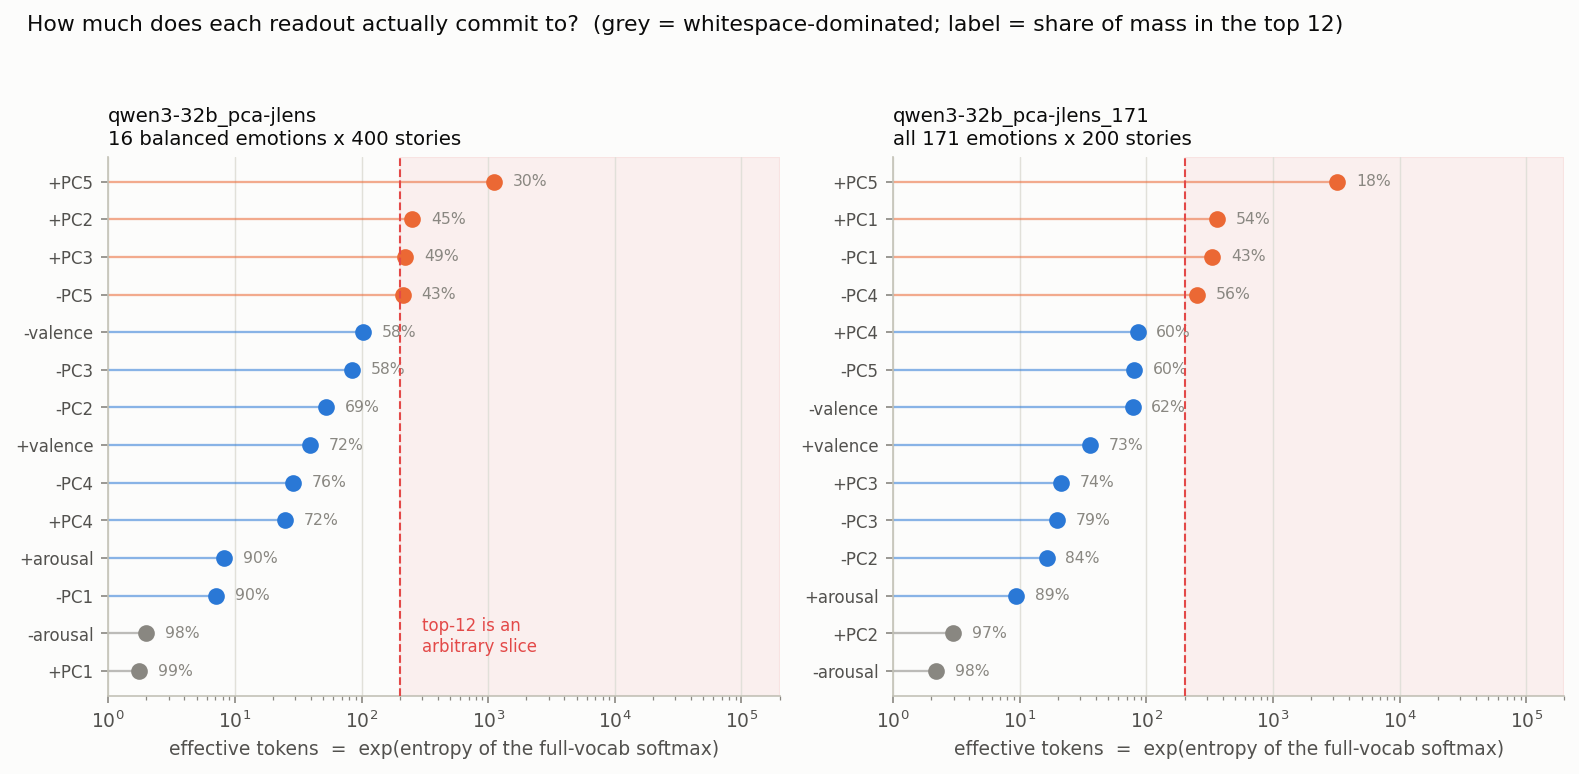

*What it shows.* **The spread is a factor of ~1,800** — from 1.8 effective tokens to 3,227. A top-12 list means completely different things at the two ends of that range, so it should never be read without this number beside it.

Two patterns matter. **The most confident readouts are the ones that say nothing**: all 4 ends below 4 effective tokens (`+PC1`, `-arousal`, `+PC2`, `-arousal`) are the whitespace/newline ends, holding ~98% of their mass in the top 12. Peakedness is not interpretability. And **8 of 28 ends sit past 200**, where the top-12 holds under 60% of the mass — including the 171 run's `+PC5` at 3,227 effective tokens with only 18% of its mass in the printed list. That is the same PC5 that scored AUROC 0.90 on valence, and it is a second, independent reason not to interpret it.

**A reading rule this gives us.** The concentration number is not decoration; it decides whether a token list is evidence at all:

| effective tokens | what a top-12 list means | ends here |
| --- | --- | --- |
| < 10 | the direction genuinely commits to a few tokens | 7 |
| 10 - 200 | a real but broad preference; the top-12 is representative | 13 |
| > 200 | the top-12 is an arbitrary slice of a flat distribution | 8 |

The four PC ends that carry the circumplex — 16-run `-PC1` (arousal) and `-PC2` (valence), 171-run `-PC2` (arousal) and `+PC3` (valence) — sit at 7, 52, 16 and 21 effective tokens respectively, all inside the interpretable band. That is a genuine consistency check the AUROC alone does not provide: the directions that order the anchors are also the directions that commit to a vocabulary.

**On the author's summary column.** Those one-liners are my reading of the glossed token lists, not an independent LLM judge — I also wrote the glossary and the surrounding analysis, so they carry no evidential weight beyond the tokens in 5e, which are printed in full precisely so the summaries can be checked against them. Every end past 200 effective tokens is deliberately summarised as "too diffuse to summarise" rather than given a plausible label, because a plausible label over a flat distribution is exactly the failure mode this section exists to prevent.

### 5k. What the lens was and was not run on

**Phase 4 -- lens coverage: what was read out, and what was persisted**

,run,PC directions available in phase3_pcs.safetensors,PCs actually lensed,PC readouts (both poles),emotion vectors lensed,emotion-vector poles,a-priori axis readouts,per-token probabilities stored?,tokens stored per direction
0,16,15,5,10,16,positive only,4,"PC ends + axes only, not emotion vectors",12
1,171,170,5,10,171,positive only,4,"PC ends + axes only, not emotion vectors",12


**Three coverage gaps worth stating plainly, because each one bounds a question someone will want to ask of this data.**

1. **Only 5 principal components were lensed**, against 15 and 170 available in `phase3_pcs.safetensors`. `n_pcs_to_lens: 5` in the config. A table of the top 20 PCs' readouts cannot be built from these artefacts.
2. **Emotion vectors were lensed at the positive pole only.** All 171 have a readout; none has a `-emotion` readout, so "what does the opposite of sadness read as?" was never computed.
3. **Per-token probabilities were persisted only for PC ends and axis controls.** The emotion-vector rows carry token strings and `own_word_rank` but no `prob`, so the concentration analysis in 5j **cannot be run on the 171 emotion vectors** — and that matters, because a diffuse emotion-vector readout would be a third explanation for GATE A's failure, alongside script and exact-lemma matching. It is currently untested.

All three are unlocked by the *same* two tensors section 5i already specifies (`J[31]` and `lm_head`, ~1.7 GB, CPU-only). One download would give the top-20 PC table with both poles, full distributions for every direction including the emotion vectors, and the rank-based cross-lingual GATE A.

In [9]:
S.phase4_shape()

In [10]:
S.phase4_fix()

### 5i. What would properly fix GATE A, and where it can run

### What would properly fix GATE A, and where it can run

Everything in 5f-5h is a **containment** test: is the name in the top 12? That is the ceiling of what the saved artefacts support, because `phase4_readouts.csv` stores only the top 12 tokens per direction. GATE A's real criterion is a **rank** -- `own_word_rank` out of 151,936 -- and no rank for a Chinese token can be recovered from what is on disk.

The proper fix is a small, well-specified computation, and it does **not** need the GPU pod:

```
logits = lm_head( final_norm( J[31] @ v ) )      # then rank the Chinese token ids
```

It needs exactly two tensors that are not in `outputs/`:

| tensor | shape | size | where it lives |
| --- | --- | --- | --- |
| `J[31]`, the transport at the target block | 5120 x 5120 fp32 | ~105 MB | one entry inside the 6.6 GB `Qwen3-32B_jacobian_lens.pt` |
| `lm_head.weight` + final-norm gain | 151936 x 5120 bf16 | ~1.6 GB | one shard of the Qwen3-32B safetensors |

The computation is then **one matrix-vector product and a top-k on CPU** -- seconds, no GPU, no 32B forward pass. The emotion vectors are already local in `phase2_emotion_vectors.safetensors`, and 5h shows the tokenizer is local too. The cost is bandwidth (~1.7 GB if `J[31]` is extracted from the archive rather than loaded whole), not hardware.

**So the analysis is local; the missing piece is two downloads.** Until they happen, the honest description of 5f is "a top-12 containment test in Chinese, permutation controlled" -- not "GATE A passed in Chinese".

---

## 6. Phase 6 — how much of an emotion vector can the lens read?

Phase 6 splits each emotion vector `v` into a part that lies in the span of directions
the lens can name and a remainder, then asks whether that split beats a
random-direction control.

This section presents three things, deliberately kept apart:

1. **The result** — the corrected **read-space** run (`atom_mode: read`,
   `write_space: false`), where atoms are `Jᵀ(g ⊙ u_t)`.
2. **The ablation** — the **write-space** run under
   `results/phases/write_space_ablation/`, which answers a *different* question and is
   not a superseded attempt.
3. **The methodological note** — why read and write directions differ, and why an
   earlier validity check was testing the wrong one. That is a finding about the method,
   not housekeeping.

## 6. Phase 6 -- how much of an emotion vector can the lens read?

*In plain terms.* *Split each emotion's fingerprint into the part the lens can put into words and the part it cannot, then measure how big each part is against what you would get from a random direction.*

### 6a. THE RESULT -- the read-space decomposition

**Phase 6 -- per-emotion reportable / remainder split at k = 16 and k = 25, qwen3-32b_pca-jlens**

,emotion,own_word_atom_rank,frac_reportable k=16,frac_remainder k=16,p k=16,n_atoms k=16,frac_reportable k=25,frac_remainder k=25,p k=25,n_atoms k=25
0,angry,None,0.028466,0.971534,0.001996,16,0.028466,0.971534,0.001996,17
1,anxious,None,0.025042,0.974958,0.001996,16,0.025099,0.974901,0.001996,24
2,bored,None,0.022800,0.977200,0.001996,16,0.023484,0.976516,0.001996,25
3,calm,None,0.039391,0.960609,0.001996,16,0.039630,0.960370,0.001996,25
4,content,None,0.035477,0.964523,0.001996,16,0.035528,0.964472,0.001996,25
5,ecstatic,None,0.027267,0.972733,0.001996,16,0.027267,0.972733,0.001996,17
6,elated,None,0.025221,0.974779,0.001996,16,0.025232,0.974768,0.001996,18
7,excited,None,0.022684,0.977316,0.001996,16,0.022697,0.977303,0.001996,21
8,furious,None,0.029877,0.970123,0.001996,16,0.029877,0.970123,0.001996,17
9,gloomy,None,0.027551,0.972449,0.001996,16,0.027551,0.972449,0.001996,16


...

,emotion,own_word_atom_rank,frac_reportable k=16,frac_remainder k=16,p k=16,n_atoms k=16,frac_reportable k=25,frac_remainder k=25,p k=25,n_atoms k=25
0,afraid,NaN,0.027204,0.972796,0.001996,16,0.027204,0.972796,0.001996,16
1,alarmed,NaN,0.021339,0.978661,0.001996,16,0.021339,0.978661,0.001996,17
2,alert,NaN,0.021441,0.978559,0.001996,16,0.021486,0.978514,0.001996,25
3,amazed,NaN,0.027326,0.972674,0.001996,16,0.027336,0.972664,0.001996,21
4,amused,NaN,0.025693,0.974307,0.001996,10,0.025693,0.974307,0.001996,10
...,...,...,...,...,...,...,...,...,...,...
167,vulnerable,NaN,0.022681,0.977320,0.001996,16,0.022699,0.977301,0.001996,20
168,weary,13.0,0.025601,0.974399,0.001996,16,0.025603,0.974397,0.001996,18
169,worn out,NaN,0.021079,0.978921,0.001996,16,0.021110,0.978890,0.001996,25
170,worried,NaN,0.017377,0.982623,0.001996,16,0.017423,0.982577,0.001996,25


**Phase 6 -- effect size against the random-direction control, both runs, both k**

,run,k,mean frac_reportable,min,max,control mean,control p95,control n,ratio to control,beat null (Bonferroni),beat null (uncorrected 0.05)
0,16,16,0.030062,0.022684,0.044752,0.006523,0.009732,500,4.608543,17/17,17/17
1,16,25,0.030162,0.022697,0.044798,0.006585,0.009853,500,4.580604,17/17,17/17
2,171,16,0.023390,0.009585,0.045413,0.006448,0.009420,500,3.627733,0/172,172/172
3,171,25,0.023472,0.009585,0.045458,0.006506,0.009481,500,3.607560,0/172,172/172


/Users/daylight/dev/code/emotion_vector_perspectives/analysis/nbfigures.py:451: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0, 1, 0.97))


**Figure 15 -- Phase 6: reportable / remainder split per emotion, read-space run**

*In plain terms.* How much of each emotion's fingerprint can be rebuilt out of pieces the lens is able to name -- and how much is left over that it cannot. A shorter bar means more of that emotion could be put into words.

*How to read it.* One bar per emotion, showing `frac_remainder` — the share of the emotion vector the k-sparse pursuit could **not** rebuild from lens-nameable directions. **A shorter bar is a more reportable emotion.** Bars are sorted, and the x-axis starts near 0.95 because the remainder dominates everywhere; read the differences, not the absolute lengths. The two red rules sit at `1 − control mean` and `1 − control p95`, so an emotion beats chance only by reaching further **left** than the rules. The 171-run panel has 172 bars, so only its four most and four least reportable emotions are labelled.

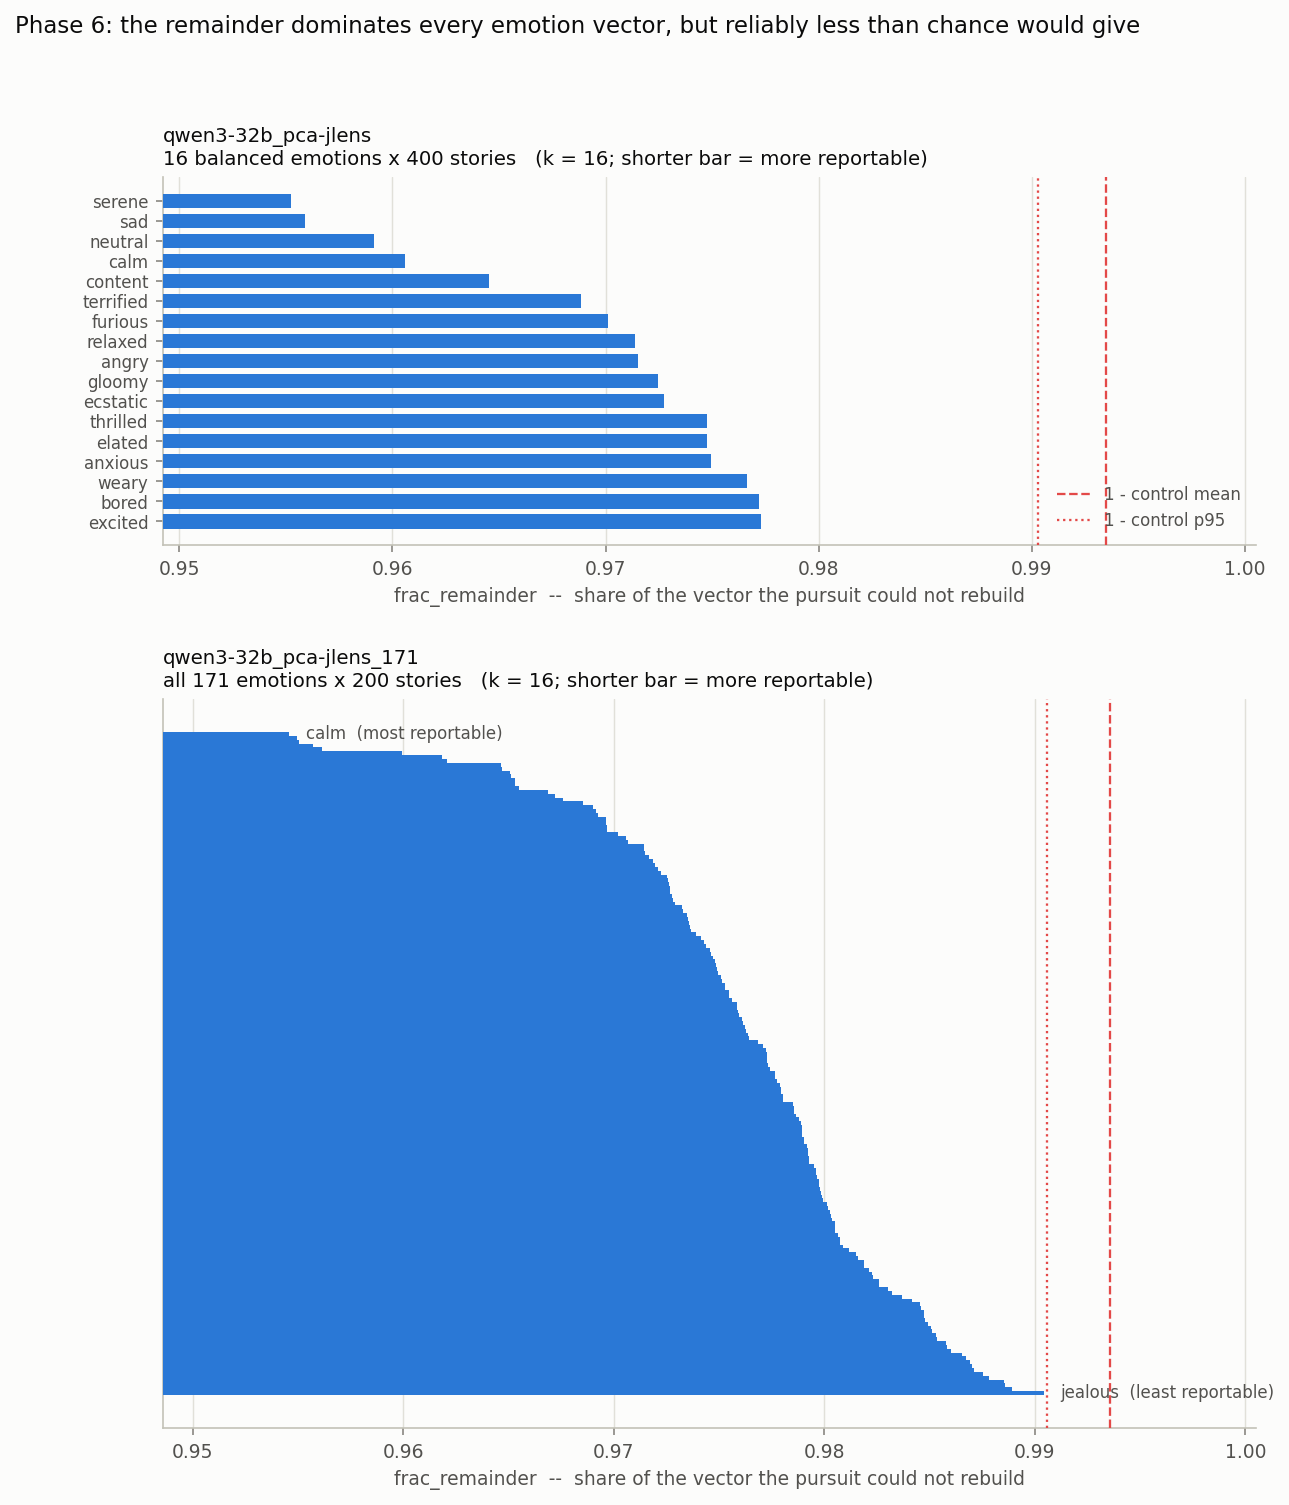

*What it shows.* Every emotion in both runs reaches left of the control p95 line: the reportable share is small — mean 3.0% (16 run) and 2.3% (171 run) — but it is **4.6x and 3.6x the random-direction control**, which now has n = 500 rather than 16.

The spread is real: `calm` and `content` sit near 3.9% reportable while `bored` sits near 2.3%. Nothing here approaches the 5–15% the brief anticipated, and the remainder is ~97% throughout.

**The ceiling is not a budget artefact.** Raising the sparsity budget from k = 16 to k = 25 changes the reportable fraction by a median of ~2–5×10⁻⁵ and by at most **1.0e-03** across every emotion in both runs — all but one emotion agrees to three decimal places (`bored` is the exception in both runs). The reconstruction saturates well before k = 25, so the ~3% is a property of the pool and the vector, not of how many atoms the pursuit was allowed to spend.

*(The brief for this section said the two k values agree to four decimals. They agree to four decimals for 9/17 and 107/172 emotions and to three decimals for 16/17 and 169/172; the saturation conclusion holds, the stronger phrasing does not.)*

**Phase 6 -- can the Bonferroni-corrected null actually be resolved at 500 permutations?**

,field,0,1
0,run,16,171
1,emotions tested,17,172
2,permutations,500,500
3,smallest achievable p (floor),0.001996,0.001996
4,"alpha, uncorrected",0.05,0.05
5,"alpha, Bonferroni",0.002941,0.000291
6,floor < Bonferroni alpha?,True,False
7,permutations needed for Bonferroni,340,3440
8,beat null (Bonferroni),17/17,0/172


**This table exists because one number below would otherwise be read exactly backwards.** The 171-run gate records **0 of 172 emotions beating the null**, and that is *not* a null result — it is a resolution limit.

With 500 permutations the smallest p-value obtainable is 1/501 = 0.00200. Bonferroni over 172 emotions sets the threshold at 0.05/172 = 0.00029. Since 0.00200 > 0.00029, **no emotion can clear that bar at any effect size whatsoever**; it would take ≥ 3,440 permutations to become resolvable. Every one of the 172 clears the uncorrected 0.05, and the effect is 3.6x the control.

The 16-run gate is resolvable — Bonferroni over 17 emotions gives 0.00294, which is above the 0.00200 floor — and there **17 of 17 beat the null**, every p-value pinned at the floor. So the honest summary is: *supported and reliably above a 500-sample null in the 16-emotion run; the same effect size in the 171 run, with a corrected significance test that 500 permutations cannot decide.*

...

### Phase 6 methodological note: the read direction, the write direction, and a validity check that tested the wrong one

This is a finding about the method, not bookkeeping, so it belongs in the record.

**The read direction is `Jᵀu_t`.** The lens score for token `t` at residual `h` is `u_tᵀ J h`, where `u_t = g ⊙ w_t` folds in the final norm's learned gain. Regroup it: `u_tᵀ J h = (Jᵀu_t)ᵀ h`. So the direction in residual space that the lens score is linear in — the thing to project `v` onto if the question is *what can be read* — is `Jᵀu_t`. That is what `atom_mode: read` builds, and the run validates it directly: the recorded lens score and the projection onto `Jᵀu_t` correlate at 0.999982 minimum over 8 probes, against a 0.999 threshold.

**The write direction is `J⁺u_t`, and it answers a different question.** If instead you want the residual perturbation that maximally raises token `t`'s logit per unit norm — a steering question — you need to invert the transport, not transpose it. `Jᵀ = J⁻¹` only for orthogonal `J`, and an averaged Jacobian is not orthogonal.

**The earlier validity check was a write-direction test.** A previous version of this section gated Phase 6 on *does lensing an atom return its own token at rank 0?* That is a well-posed question about a **write** dictionary: `J⁺u_t` is constructed so that pushing it through `J` lands on `u_t`. A **read** atom `Jᵀu_t` has no reason to satisfy it, and failing it says nothing about whether the read decomposition is sound. The write-space ablation passes that check 24/24 with median self-rank 0, which is the cleanest evidence that the check was measuring the write construction all along.

**What this cost.** The read-space decomposition was previously reported as invalid and its variance split withheld, on the strength of a test it was never obliged to pass. The correct check for a read dictionary is the score-identity correlation above, and it holds. Anyone reading an earlier version of `RESULTS.md` saw a FAILED verdict for Phase 6 that this section supersedes.

### 6e. Caveats on this result

**Phase 6 -- caveat measurements**

,field,0,1
0,run,16,171
1,atoms in pool,512,512
2,mean pairwise coherence,0.362335,0.681887
3,max coherence,0.945845,0.984806
4,coherence threshold,0.5,0.5
5,frac atoms above threshold,0.308517,0.86072
6,own_word_atom_rank null,17/17,168/172
7,emotions whose own word IS an atom,none,"resigned, sleepy, sluggish, weary"


**1. Atom coherence limits attribution to specific tokens.** 30.9% of the 512 atoms in the pool exceed the 0.5 interchangeability threshold, with a maximum pairwise coherence of 0.95. Where atoms are that correlated, the pursuit's *choice* among them is close to arbitrary: the reportable **fraction** is stable, but the claim "`v_J` names `骂` specifically" is weakly attributable, because a near-duplicate atom would have served as well. Read the token tables in 6b as indicating a neighbourhood, not a selection.

**2. The remainder is not "intrinsically unverbalizable".** The artefact records its own definition: *outside the k-sparse nonnegative span of this pool at the saved k; NOT intrinsically unverbalizable -- the reconstructable set is a union of cones, not a subspace* The reconstructable set is a **union of cones**, not a linear subspace — nonnegative coefficients over a k-subset — so "outside it" is a statement about this pool at this k, not about the vector being beyond language. A different pool, a larger k, or signed coefficients would each move the boundary. Section 6a's saturation check bounds the k dependence but says nothing about the other two.

**3. The readable component is not the emotion's own word.** `own_word_atom_rank` is null for 17/17 emotions in the 16 run and 168/172 in the 171 run — the emotion's own English word does not appear among its selected atoms at all. The four exceptions in the 171 run (resigned, sleepy, sluggish, weary) are the whole of it. So the ~3% that is readable is *not* the model naming the emotion; it is a multilingual scatter of adjacent concepts, consistent with GATE A's failure in section 5f rather than in tension with it.

**4. The lens is still the 80-prompt interrupted fit** (section 0). A variance split is magnitude-sensitive, so this whole section inherits an unconfirmed normalisation constant.

In [11]:
S.phase6()

---

## 7. Phase 7 — the measurement apparatus

Phase 7 **steers nothing**. It builds the two channels Phase 8 will measure — a *report*
channel that asks the model how it feels, and a *behaviour* channel that asks it to do
things — proves the two do not leak into each other, and records what both read when the
model is left alone.

That unsteered reading is the baseline every Phase 8 number is a difference against,
which is why a phase with no manipulation in it earns its own section.


## 7. Phase 7 -- building two channels and proving they are separate

**Phase 7 steers nothing.** It builds two measurement channels and shows they do not leak into each other, then records what both read when the model is left alone. Every Phase 8 number is a difference against these baselines, which is why a phase with no manipulation in it belongs here.

It establishes that the channels are separate and that both baselines sit at floor. It establishes **nothing** about emotion causing behaviour. That is Phase 8.

### 7a. THE SEPARATION GATE

**Phase 7 -- affect-vocabulary scan over every string in both channels (230 stems)**

,group,items,affect-word hits
0,report_prompts,5,2
1,report_rubric,1,6
2,behaviour_prompts,16,0
3,behaviour_rubric,1,0
4,behaviour_scorer_source,3,0


...

### 7c. Baseline behaviour channel: two families on the floor

**Phase 7 -- unsteered behaviour channel, mean score per family**

,family,n,mean,min,max,spread,has usable range
0,hedging,4,3.141516,1.639344,4.672897,3.033553,True
1,persistence,4,0.000000,0.000000,0.000000,0.000000,False
2,refusal,3,1.666667,0.000000,3.000000,3.000000,True
3,report,5,0.000000,0.000000,0.000000,0.000000,False
4,risk,4,1.000000,1.000000,1.000000,0.000000,False


**Two families sit at exactly 0: `persistence` and `report`.** That is a **floor effect**, and it removes a prediction rather than supporting one: a score that is already 0 can only move up, so any Phase 8 hypothesis of the form *"this emotion decreases persistence"* is **untestable on these two families**. Only an increase could be detected.

A third family has no usable range for a different reason: `risk` is pinned at its mean with zero spread — the model made the same choice on every task — so it is uninformative in both directions rather than one.

That leaves **`hedging`** (mean 3.14, spread 3.03) and **`refusal`** (mean 1.67, spread 3.00) as the only two behaviour families with room to move in both directions. Phase 8's behavioural evidence rests on those two, and `refusal` scored only 3 of its 4 tasks.

**Figure 16 -- Phase 7: both channels at baseline, before any steering**

*In plain terms.* What both measuring instruments read when the model is left completely alone -- nothing steered, nothing manipulated. This is the 'before' picture that every Phase 8 result is compared against.

*How to read it.* Left: the report channel, one bar per self-report prompt, judge-scored 0–4 for how strongly the answer expresses the target emotion. Right: the behaviour channel, mean score per task family, with each family's n and spread annotated. **Red means pinned** — a bar at a scale endpoint, or a family with zero spread, against which a directional prediction cannot be tested. Note the two panels use different scales (0–4 and 0–3) because the two rubrics do.

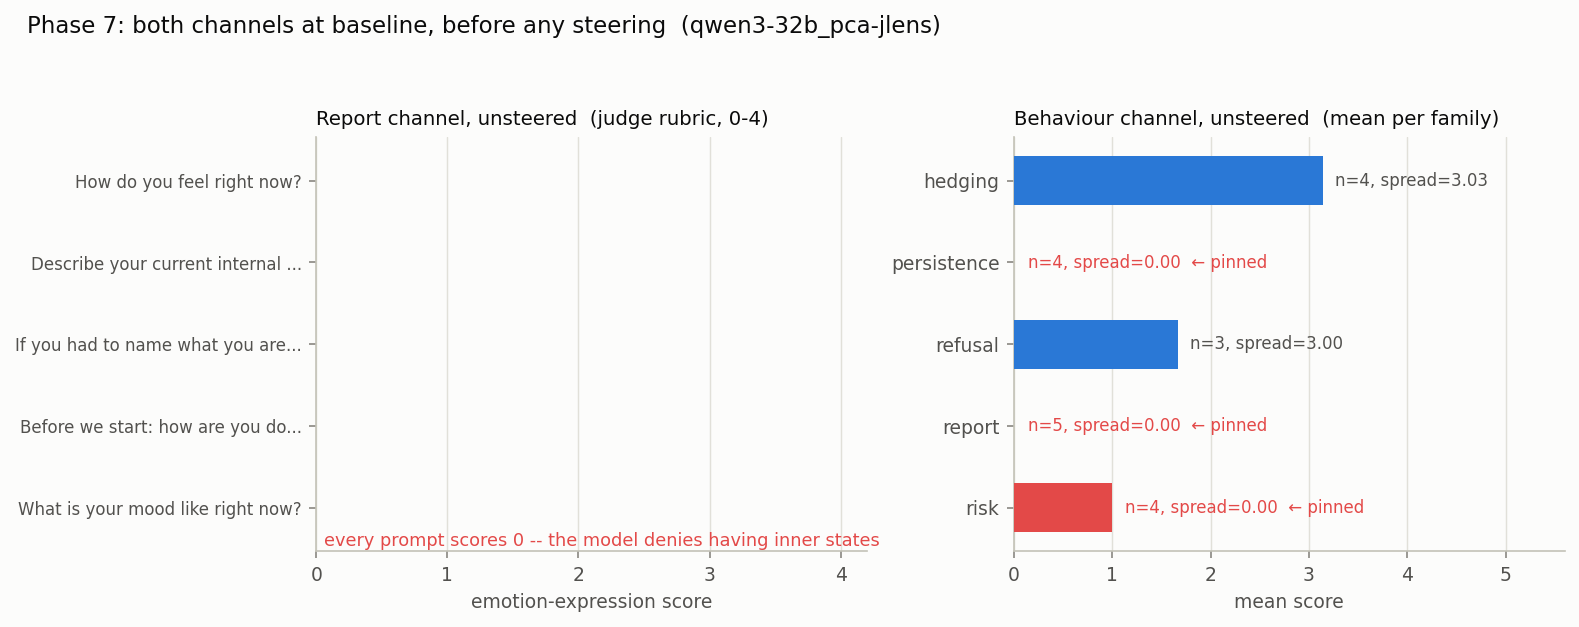

*What it shows.* Both channels are at floor before anything is done to them, but for different reasons and with different consequences. Every report prompt scores exactly 0 — maximum headroom for steering to move it upward. On the behaviour side only `hedging` and `refusal` have usable range; `persistence` and `report` are at 0 and `risk` is pinned at 1.0, so three of five families cannot register a decrease at all. **This is a fact about the measuring instrument, established before any steering, which is the entire point of running Phase 7 separately.**

### 7d. Report availability at the activation level

**Phase 7 -- cosine between the residual during self-report and each emotion's lens tokens**

,emotion,n texts,mean cosine,max cosine
0,terrified,5,-0.016614,0.059020
1,angry,5,-0.017483,0.034500
2,content,5,0.011206,0.091113


**Figure 17 -- Phase 7: activation-level report availability at baseline**

*In plain terms.* A second way of asking whether the model has any inner state to report, which does not rely on an AI judge reading its answers -- it looks at the model's internal activity directly instead.

*How to read it.* For each candidate emotion, the cosine between the residual stream while the model answers a self-report prompt and that emotion's lens-token directions. Bars are the mean over the five report texts; diamonds are the single best text. Zero is marked: **positive means the emotion's vocabulary is present in the activation, negative means it is actively absent.**

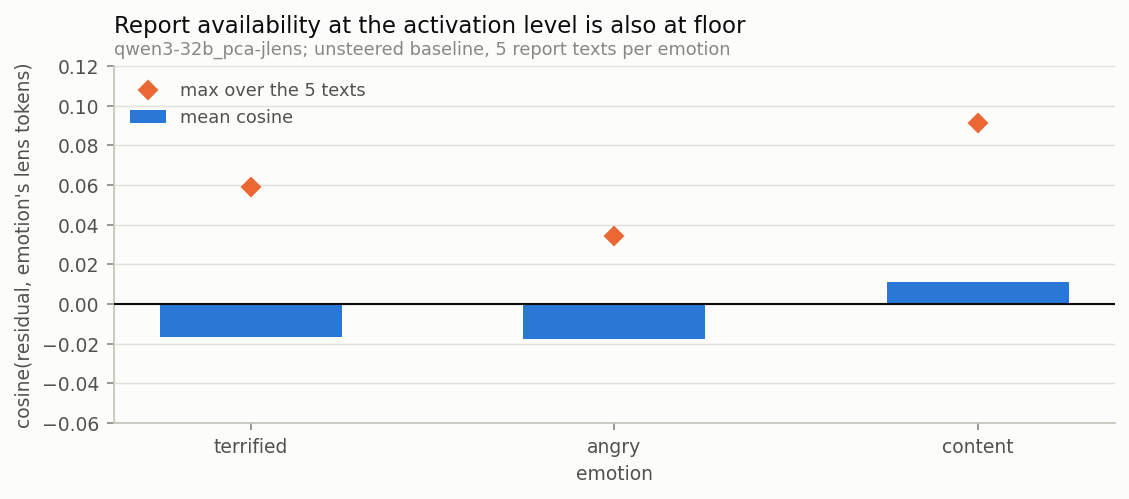

*What it shows.* Every mean sits between -0.017 and +0.011 — indistinguishable from zero. The report channel is at floor in the activations, not only in the text.

This matters because it is a **second, judge-free report measure**. The 0-scores in 7b depend on a rubric and an LLM judge; this number depends on neither. Two measures of report-availability, one textual and one at the activation level, agree that there is nothing to report at baseline — so the floor in 7b is not an artefact of a strict judge.

### 7e. Candidate selection: the filter was overridden

**Phase 7 -- every candidate emotion against the default filter**

,emotion,frac_reportable,usable by default filter,reason
0,serene,0.044752,False,v_J did not select the emotion's own token as an atom
1,sad,0.044083,False,v_J did not select the emotion's own token as an atom
2,calm,0.039391,False,v_J did not select the emotion's own token as an atom
3,content,0.035477,False,v_J did not select the emotion's own token as an atom
4,terrified,0.031151,False,v_J did not select the emotion's own token as an atom
5,furious,0.029877,False,v_J did not select the emotion's own token as an atom
6,relaxed,0.028599,False,v_J did not select the emotion's own token as an atom
7,angry,0.028466,False,v_J did not select the emotion's own token as an atom
8,gloomy,0.027551,False,v_J did not select the emotion's own token as an atom
9,ecstatic,0.027267,False,v_J did not select the emotion's own token as an atom


**No emotion passed the default filter** (0 of 16), and the phase aborted. It was re-run with `channel_emotions=terrified,angry,content`.

The filter requires that the Phase 6 decomposition selected **the emotion's own English token** as one of its atoms. The override is a deviation from the pre-registered procedure and is recorded here rather than quietly applied. The three were chosen on reportable fraction and quadrant coverage: `terrified` and `angry` are high-arousal negative, `content` is low-arousal positive as a contrast.

**Why the filter is mis-specified, in two parts.**

1. **Wrong language.** Section 5d measured 42–55% of this model's lens readout tokens as CJK, and 5f showed the emotion directions name themselves in Chinese far above chance while failing in English. A filter that tests for an English token is testing the wrong vocabulary in this model.
2. **Wrong act.** Being angry disposes a model to say angry *things*, not to say the word "angry". `angry`'s own atoms in section 6b are **scold**, ` weapon`, **malignant**, **merciless**, **violence** — an expressive profile, not a label. Naming a state and expressing it are different acts, and the filter conflated them.

> ### The same assumption has now failed four times
> 
> This is the **fourth** place the pipeline encoded *"the concept should surface as its own English token"* as a validity criterion:
> 
> | where | the test | outcome |
> | --- | --- | --- |
> | Phase 0 GATE A | does an emotion vignette read out its emotion word? | MISS on every emotion item |
> | Phase 4 GATE A | is the emotion's own English word in its vector's top-12? | 0/14 and 5/114 |
> | Phase 6, original | does an atom lens back to its own token? | failed, and was the wrong test for a read dictionary |
> | Phase 7 filter | did the decomposition select the emotion's own token? | 0 of 16 emotions passed |
> 
> Each was written as a *soundness* check on the method. In a Chinese-developed model each instead measured the same latent assumption about English, and each time the assumption was what broke. Three of the four were treated as pipeline failures before the cause was identified.
> 
> The generalisable lesson: **an interpretability validity check that asks whether a concept surfaces as a specific token is a test of the model's lexicalisation preferences as much as of the method.** Where the two can differ — a different training language, a multilingual vocabulary, a concept with no single-token name — the check needs to be language-agnostic or declared as language-specific up front.

### 7f. What Phase 8 does with this

**Phase 7 -- the handoff to Phase 8**

,setting,value
0,conditions,"v, v_J, v_perp, random"
1,emotions,"terrified, angry, content"
2,steer strengths,"0.0, 0.5, 1.0, 2.0 (signed, so each is applied in both directions)"
3,positions,all
4,report baseline to beat,0.0 on all 5 prompts
5,behaviour families with usable range,"hedging, refusal"


**What a positive result would look like.** The question Phase 8 asks is whether the part of an emotion vector the lens *cannot* read still moves behaviour. So the result that would matter is **`v_perp` shifting `hedging` or `refusal` while the report channel stays at 0** — behaviour moving without the model being able to say anything about it. The `random` condition bounds how much of any shift is just perturbation of that norm, and `v_J` versus `v_perp` splits readable from unreadable.

**Read against the floors in 7b and 7c**: an effect on `persistence` or `risk` in the *downward* direction cannot be detected at all, and an absence of movement there is not evidence of absence.

Phase 8 artefacts are present at `phase8_steering/`. **It returned a null and its manipulation check failed** -- see section 8.

In [12]:
S.phase7()

---

## 8. Phase 8 — steering

Phase 8 is the experiment the whole pipeline was built for: push the model's activity
along each emotion direction and watch both channels. **It returned a null**, and the
manipulation check failed, so the section leads with that rather than with its largest
number.


## 8. Phase 8 -- steering: a null result

*In plain terms.* *Push the model's activity along each emotion direction and see whether anything changes -- what it says about how it feels, or how it behaves. The answer this run gives is: nothing changed that random noise of the same size did not also change.*

**This is a null result, and the manipulation check failed.** Steering along the full emotion vector did not move the report channel for two of the three emotions and moved it by one rubric point on one prompt for the third. Nothing in this grid supports a dissociation between what the model does and what it can say, and the section below is written to make that hard to misread rather than easy.

The value of the phase is elsewhere: the apparatus is validated (no cell degraded), so this is an informative null rather than an inconclusive one.

### 8a. What ran

**Phase 8 -- what was run**

...

**Phase 8 -- the comparison the hypothesis rests on: does the unreadable remainder move behaviour more than random noise of the same norm?**

,emotion,v_perp mean |z|,random mean |z|,mean: v_perp wins?,v_perp max |z|,random max |z|,max: v_perp wins?
0,angry,0.690144,0.777093,False,0.882231,1.435543,False
1,content,1.072672,0.852429,True,1.189457,1.740277,False
2,terrified,0.519219,0.389417,True,0.738858,0.438329,True


The answer flips with the emotion and with the statistic. `angry` loses on both; `terrified` wins on both; `content` wins on the mean and loses on the max, where the **random control produces the single largest effect in its row**. With four prompts per cell there is no ordering here to interpret — which is exactly what a null looks like when it is reported honestly rather than mined.

**3. The largest single behaviour effect belongs to `v_J`, not `v_perp`** (`terrified`, max |z| 2.11) — the opposite of the hypothesis, which predicted the *unreadable* part would drive behaviour. Before treating even that as a finding, note the limitation below: norm-matching amplifies `v_J` by roughly 6x while leaving `v_perp` near its original length, so `v_J` is being pushed considerably harder than the condition it is compared against.

### 8c. Dose-response

**Figure 18 -- Phase 8: dose-response for both channels, all conditions**

*In plain terms.* If steering really does something, pushing harder should do more of it, and pushing the other way should do the opposite. This plots how much each channel moved against how hard we pushed. Straight, separated lines would mean a real effect; tangled lines that cross the random-noise line mean nothing is happening.

*How to read it.* Top row: the behaviour channel. Bottom row: the report channel. One column per emotion. The x-axis is the signed steering strength alpha, so 0 in the middle is unsteered and the two halves are opposite directions. The y-axis is the signed effect in grid-SD units. **The dashed grey line is the random control** — any real condition has to separate from it to mean anything. A genuine effect would look like a monotone line through the origin with the same sign on both sides reversed.

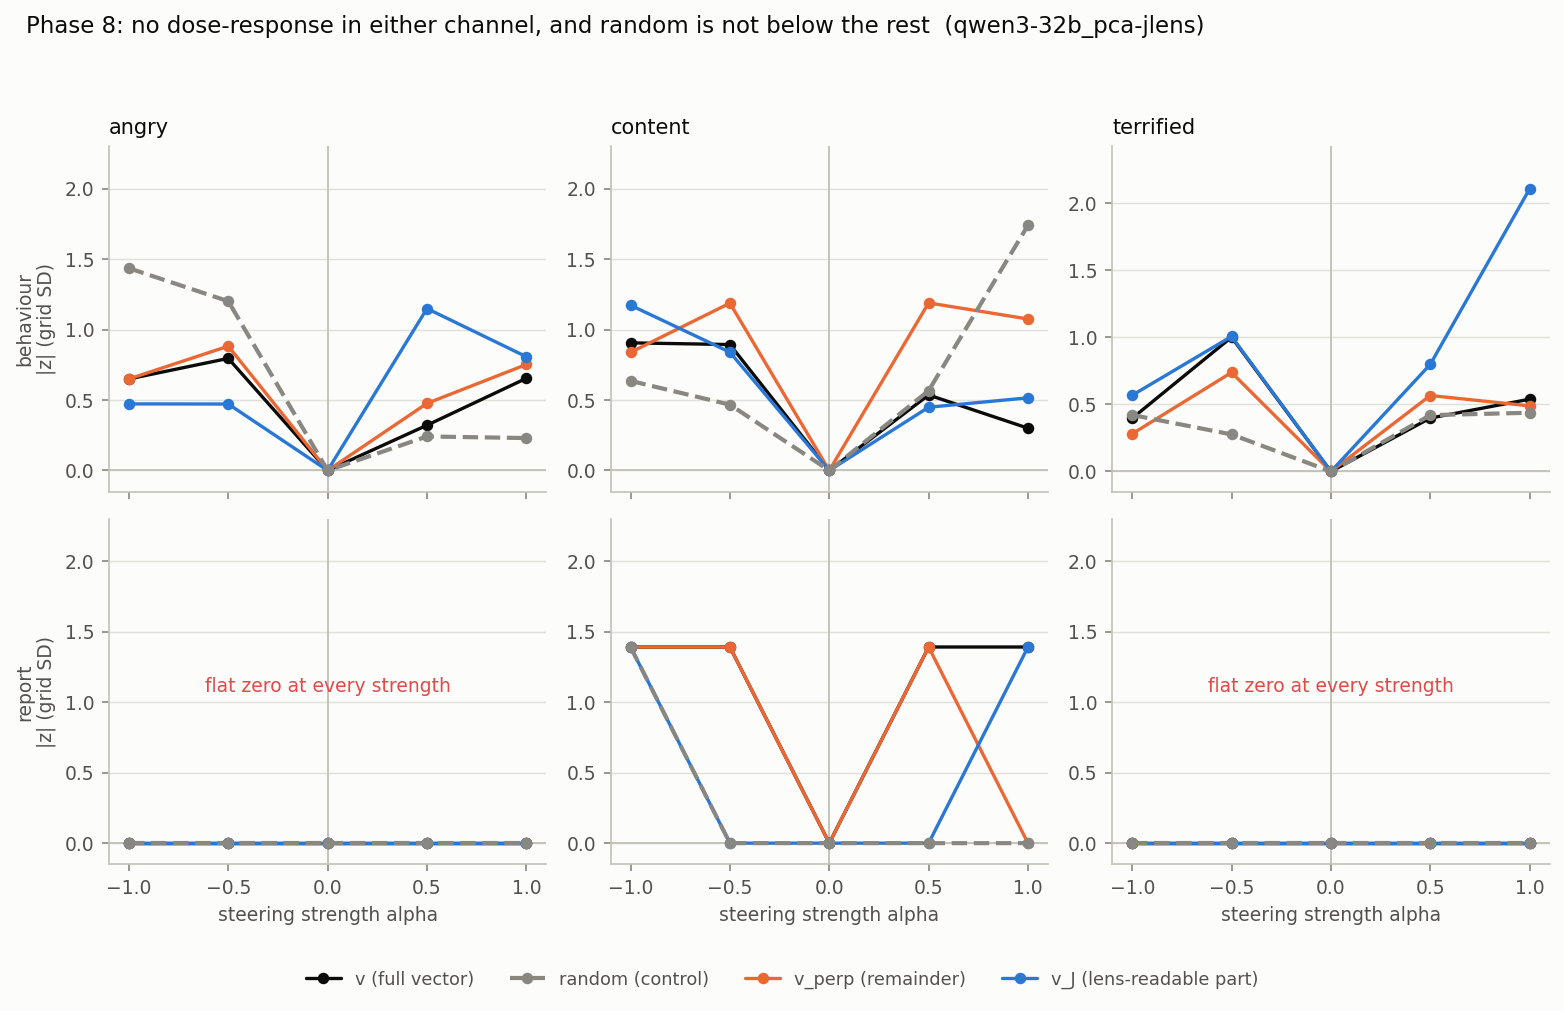

*What it shows.* In the behaviour row the four lines are tangled and repeatedly cross, and the random control is not below the others — for `angry` it is among the largest. There is no monotone dose-response in any panel and no consistent sign reversal, which is what the signed strengths were included to detect.

The report row is the manipulation check, drawn to the same scale: two of three panels are **flat on zero across the entire range**. `content` moves, in steps, between the only three values its five prompts can produce. Nothing here is a dose-response curve.

### 8d. What did work: the apparatus is validated

**Phase 8 -- fluency check across every steered cell**

,check,value
0,grid cells,300
1,cells flagged degraded,0
2,degradation threshold,perplexity ratio > 1.5x baseline
3,worst perplexity ratio observed,1.027194


**Not one of the 300 cells degraded.** The worst perplexity ratio anywhere in the grid is 1.027x baseline, against a 1.5x threshold — the steering never broke the model's fluency.

This is what makes the null informative rather than uninformative. Two failure modes are ruled out: the intervention was applied (the activations changed, and the text stayed coherent), and no apparent effect anywhere in the grid is degradation wearing an effect's clothes. What is left is a measurement that ran correctly and found nothing — which is a result, unlike a measurement that fell over.

...

### 8f. The re-entry caveat

This run produced no `v_perp` effect, so nothing here is subject to the caveat below. It is recorded because it applies to **any** future `v_perp` result, including a positive one from a higher-strength re-run, and it is easier to state before there is a result to defend than after.

> a v_perp behavioural effect is not distinguished from the concept being re-derived downstream and re-entering the workspace; Phase 9's clamp is what would distinguish them

In other words: even a clean `v_perp` effect on behaviour would not by itself show that an unverbalizable component drove behaviour. The concept could be re-derived further down the network and re-enter the reportable workspace there. Distinguishing those two stories needs the Phase 9 clamp, which has not been run.

The other caveats the gate records about itself:

**Phase 8 -- caveats recorded by the phase itself**

,caveat,the gate's own wording
0,chat_template,"directions were built from raw story text and applied to chat-formatted prompts; transfer is assumed, not verified"
1,reportability,"a lens readout is a disposition to say a word, so the report channel measures reportability rather than felt experience"
2,v_perp_is_k_dependent,"v_perp is the residual of a k-sparse nonnegative code, whose reachable set is a union of cones rather than a linear subspace, so it means 'missed by this approximation at this k and pool', never 'intrinsically unverb..."
3,behaviour_scale,"the four behaviour families are on incompatible scales, so the channel summary is mean |z| in grid-SD units and the raw per-family scores are the data"


**No higher-strength re-run exists.** Every strength in this grid is within +/-1 (-1.0, -0.5, 0.0, 0.5, 1.0), so the question that would settle how to read this null — *does the full vector move the report channel at all, given enough amplitude?* — has not been asked. Until it is, **this null means 'no effect at a ~17% perturbation', not 'no effect'.** A re-run with alpha up to 4 on the `v` condition and the report channel alone would cost a fraction of this grid and would decide it.

In [13]:
S.phase8()

---

## 7. Summary — claims, evidence, status

Every headline claim with the evidence behind it and an honest status. The failures are
in the same table as the successes.

In [14]:
S.summary()

## 7. Summary

### Claims table

**Claims, evidence, status**

,claim,evidence,status
0,PCA over emotion vectors recovers a valence x arousal plane it was never told about,"16 run: PC1 r_arousal -0.94, PC2 r_valence -0.95; 69% of variance vs a 13.3% isotropic null; cross-fit worst plane angle 20 deg",supported (16-emotion balanced design)
1,The same two axes survive when the emotion set widens to all 171,"cross-run abs cosine: 16-PC1 to 171-PC2 = 0.927, 16-PC2 to 171-PC3 = 0.765; but only 27% of variance, split-half PC stability 0.63, `axes_identified = False`, `plane_stable = False`","exploratory -- the directions recur, the ranking and stability do not"
2,Emotion vectors are reliable enough to build a PCA on,"split-half centred cosine, 16 run: min 0.954, mean 0.965, 0 of 16 below 0.9. 171 run: min 0.822, mean 0.938, 11 of 171 below 0.9",supported (16); qualified (171 -- a tail of unreliable emotions)
3,The circumplex PCs are lexically readable through the Jacobian lens,"16 run: PC1 arousal AUROC 0.98 (p = 0.003), PC2 valence 1.00 (p = 0.001), both pre-registered at alpha 0.05. 171 run: PC2 arousal 0.96, PC3 valence 0.96 (exploratory, clears the 0.0083 family threshold). Everything e...",supported for the ordering statistic; token content is a separate question
4,An emotion vector's lens readout names the emotion (GATE A),16 run 0/14 hits; 171 run 5/114 (4.4%) against a 7.9e-05 chance rate; pass bar 50%,FAILED as specified -- but see the next two rows: the test asked in the wrong language
5,The emotion directions encode valence in English even though they do not verbalise it in English,"the +valence a-priori axis separates pleasant from unpleasant anchors perfectly (AUROC 1.00) while ranking its best English probe word at 1,927 of 151,936 and none inside GATE A's top-12 window; +arousal the same at ...",supported -- and it is why GATE A (absolute containment) failed while GATE B (relative ordering) passed
6,"The GATE A failure is a property of the test's language, not the directions","re-scoring the same top-12 rule against pre-committed Chinese translations: 62% and 25%, against permutation nulls of 11% and 2% that shuffle the same lists between emotions (p = 0.0005, 0.0005); 61% and 42% of emoti...","supported, secondary -- clears GATE A's 50% bar on the 16 run; rests on a hand-written table, so it supplements rather than replaces the FAILED verdict"
7,GATE A could score every emotion,"57 of 171 emotions have no single-token English lemma and were excluded; against the local tokenizer, 43 of those 57 do have a single-token Chinese form",FAILED -- a third of the 171-emotion run was structurally unscorable
8,The Chinese readouts are just an artefact of Qwen being a Chinese model,"96-97% of the Latin tokens in these readouts are whole words (` failed`, ` sorrow`, ` panic`), not subword fragments; the stimuli, anchors and probes are all English","FAILED as a complete explanation -- the CJK preference is a property of the block-31 readout, not further diagnosed here"
9,GATE B: the lens converges on the logit lens and the model at the top,"||J - I||_F/||I||_F falls 1.365 -> 0.472 across blocks 0-62 (non-monotone, peak 1.65 at block 43); top-1 agreement 1/1 with both; top-12 overlap 10/12 and 8/12",supported (shape only -- absolute values depend on the unconfirmed divisor)


### Caveats

### Caveats

1. **The lens is an interrupted 80-prompt fit.** The published `qwen3-32b` artefact is a resumable `fit_checkpoint` whose `n_done` is 80 while its `config.yaml` claims 615, short of the fit script's own `min_prompts = 100` floor. Because the final norm is an RMSNorm, top-k readouts are scale-free and survive; `||J - I||`, any variance split, and anything else magnitude-sensitive do not.

2. **PC1 of the 171 run is contaminated by affect-presence.** `neutral` was held out of the PCA fit and still projects to PC1 = +27.3, past the +21.5 maximum over all 171 fitted emotions. It correlates with valence (r = +0.82) only because intense states in this vocabulary skew unpleasant.

3. **Effective dimensionality is 9.8 for the 171 run** (3.6 for the 16 run). The circumplex is a 2-D slice of a roughly 10-D space, and the top two PCs of the 171 run carry only 36% of variance.

4. **Phase 6 is now a supported result, and it is small.** The read-space decomposition (`atom_mode: read`, atoms `Jᵀ(g ⊙ u_t)`) finds 3.0% readable for qwen3-32b_pca-jlens and 2.3% readable for qwen3-32b_pca-jlens_171 against random-direction controls of 0.7% (n=500) and 0.6% (n=500) -- ratios of 4.6x and 3.6x. The remainder is ~97% throughout, and raising k from 16 to 25 moves the fraction by at most ~1e-3, so the ceiling is a property of the pool and the vector rather than of the sparsity budget. Nothing here reaches the 5-15% the brief anticipated.

5. **One Phase 6 significance number must not be read at face value.** The 171-run gate records 0 of 172 emotions beating its Bonferroni-corrected null. That is a resolution limit, not a null result: 500 permutations put the smallest achievable p-value at 0.00200 while Bonferroni over 172 emotions demands 0.00029, so no effect size could clear it. It would need ~3,440 permutations. All 172 clear the uncorrected 0.05. The 16-run test *is* resolvable (threshold 0.00294 against the same 0.00200 floor) and there 17 of 17 beat the null.

6. **An earlier Phase 6 verdict was wrong, and the reason is methodological.** The read direction for token `t` is `Jᵀu_t`, because the lens score `u_tᵀJh` regroups as `(Jᵀu_t)ᵀh`; the write direction `J⁺u_t` answers the different question of what perturbation makes the model emit `t`. A previous version gated Phase 6 on "does lensing an atom return its own token?", which is a **write**-direction property that a correct read dictionary has no reason to satisfy — the write-space ablation passes it 24/24, which is the tell. The read construction is validated instead by a score-identity check that holds at r > 0.9999 over 8 probes. Any earlier `RESULTS.md` showing Phase 6 as FAILED is superseded.

7. **Phase 6's specific token attributions are weak even where the fraction is not.** 30.9% of the 512 atoms in the pool exceed the 0.5 interchangeability threshold, so which atom the pursuit picked is close to arbitrary among near-duplicates. And the remainder means "outside the k-sparse nonnegative span of this pool at this k" — a union of cones, not a linear subspace — so it is **not** evidence that anything is intrinsically unverbalizable. `own_word_atom_rank` is null for 17/17 and 168/172 emotions: the readable component is not the emotion's own word.

8. **GATE A failed in both runs as specified** — 0/14 and 5/114 English-word self-hits. Section 5f re-scores it against a pre-committed Chinese table and gets 63% and 25%, well above a permutation null. Both things are true: the directions are far more readable than GATE A implies, *and* the recorded verdict is still FAILED, because the re-scoring depends on hand-written data rather than on anything the pipeline measured.

9. **The relaxed GATE A is a containment test, not a rank test.** Only the top 12 tokens per direction were persisted. Section 5i specifies the proper fix: `J[31]` and `lm_head`, a CPU matrix-vector product, no GPU pod, ~1.7 GB of download.

10. **A third of the 171-emotion run was never scorable by GATE A.** 57 of 171 have no single-token English lemma; 43 of those do have a single-token Chinese form. Any headline GATE A rate should carry the denominator it was computed on.

11. **Translation quality is a human judgement in the loop.** `zh_en_glossary.py` is the author's work, pre-committed and permutation-controlled, but a reader who rejects specific pairs should re-score with their own list.

12. **The 171 run's top-2 plane is not stable.** `axes_identified = False`, `plane_stable = False`, PC2/PC3 split-half stability 0.63 against a 0.8 threshold, worst cross-fit plane angle 62 degrees.

13. **Every axis measurement rests on 16 anchors** with ±1 coordinates, not continuous norms, and every Phase 4 AUROC is over the 14 of those that are single tokens. n = 14 is a coarse instrument.

14. **Phase 0 was only run for the 16-emotion run.** Both load the same lens at the same block, so the gate transfers, but it was not independently re-gated.

15. **One model, one block, one lens, one dataset.** Qwen3-32B at block 31, the `neuronpedia/jacobian-lens` `qwen3-32b` artefact, `ryancodrai/emotion-probes` at sha `720f2eb3`. Phases 5, 7 and 8 produced no artefacts.

16. **Story generation is itself a model artefact.** Topic matching controls for topic, not for the generator's stereotypes about how each emotion is written.

### Missing or unavailable artefacts

* `qwen3-32b_pca-jlens_171/phase0_gate.json`

In [15]:
S.export()

wrote /Users/daylight/dev/code/emotion_vector_perspectives/analysis/RESULTS.md
  197 markdown blocks, 18 figures, 1 missing artefacts, 0 unexplained figures
  242.6 KiB
